# Bacté-rivières 2026 : Data Analysis

## Notes from Slack (to be deleted)

rachel  [16 h 09https://github.com/hammerdirt/water-quality-2016-2017   Here is the data after the pandemic, used for the article:  https://github.com/Hackuarium/montreux-water-quality  This one has the 'binder' problem now...  Masoud and Carlos did most of the work there.  This one includes 22 & 23 data, and was when Roger was hoping to make articles pop out easily...    To note ->the original water work at Hackuarium was always about lake water, and our river water samples just used as 'positive controls' to show the test for the bioindicator species was working properly. This year, with Bacté-Rivières, we got to really focus on rivers, and about 15 were sampled over the sampling season (mid june-mid august)
The first open access paper came out in 2021 with all the data available on Zenodo...  It was the pandemic year sampling that gave us the contrasting results to allow us to publish (and encourage others to do the same...) https://besjournals.onlinelibrary.wiley.com/doi/10.1002/2688-8319.12094

## Links

- https://drive.google.com/drive/folders/1qfFN4roD6TY7QjWE8HPuSzKs657fmXJE
- https://github.com/hammerdirt/water-quality-2016-2017
- https://github.com/Hackuarium/montreux-water-quality
- https://besjournals.onlinelibrary.wiley.com/doi/10.1002/2688-8319.12094

## TODO

- Permutation test
- Climatic data
- Amont vs. aval

## 1. Necessary Libraries Import

In [85]:
import sys
import IPython
import math
import pandas as pd
import matplotlib
import matplotlib_inline
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from scipy.stats import norm
import seaborn as sns
from IPython.core.display import HTML
from matplotlib.ticker import SymmetricalLogLocator

In [2]:
# Réglage de l'affichage par défaut des nombres réels sur deux décimales :
pd.options.display.float_format = '{:.2f}'.format

## 2. Data Import

Measurements were saved into the following Excel (XLSX) file:

In [3]:
results_file_name = "2026-09-02_20h55_Resultats_Bacte-Rivieres_clean.xlsx"

### 2.1. Analyzed Sites

In [4]:
df_metadata = pd.read_excel(results_file_name, sheet_name='Sites')
df_metadata

,ID site,Rivière,Localisation,Coord GPS,Qui,Lieu d'incubation
0,BIE1,Bief,Lonay,2'529'592 1'153'768,Céline et Danièle,Hackuarium/Lonay
1,BIE2,Bief,Prison de la Tuilière,46'31'08.5 6'30'49.7,Yvonne et Ariane,Lonay\n
2,BMO1,Baie de Montreux Rivière,Amont,2'560'053.04 1'142'670.23,Rachel,Hackuarium
3,BMO2,Baie de Montreux Rivière,Embouchure,2'559'273.04 1'142'310.67,Rachel,Hackuarium
4,BOIM1,Boiron de Morges,Fontaine chasseurs,2'519'765 1'154'417,MDLR,MDLR
5,BOIM2,Boiron de Morges,Lussy,2'523'153 1'150'170,Maurice,MDLR
6,BOIM3,Boiron de Morges,Embouchure,2'526'282 1'149'559,MDLR,MDLR
7,BOIN1,Boiron de Nyon,Nyon2,2'506'966 1'136'977,Esther,Hackuarium
8,CHA1,Chamberonne,Amont,2'534'615 1'152'163,Objectif sciences internationales \n& Aleksandra,Camping de Vidy \n& Hackuarium
9,CHA2,Chamberonne,Embouchure,2'534'461 1'152'469,Objectif sciences internationales \n& Aleksandra,Camping de Vidy \n& Hackuarium


The above coordinates are based on the [official Swiss coordinates system (MN95)](https://www.swisstopo.admin.ch/fr/le-systeme-de-coordonnees-suisse).

### 2.2. Bacterial Colonies Measurements

In [5]:
df = pd.read_excel(results_file_name, sheet_name='Résultats', dtype={
    "Semaine": "object",
    "Nb colonies E. coli par 100 ml": "float64"
})
df.head(10)

,ID site,Echantillon,Semaine,Nb colonies E. coli,Nb colonies coliformes,Nb colonies E. coli par 100 ml,Nb colonies coliformes par 100 ml,Notes
0,COS1,A,1,NaN,NaN,NaN,NaN,NaN
1,COS1,B,1,NaN,NaN,NaN,NaN,NaN
2,COS1,C,1,NaN,NaN,NaN,NaN,NaN
3,VNX,A,1,12.00,78.00,1200.00,7800.00,turquoise esp
4,VNX,B,1,4.00,67.00,400.00,6700.00,pour VNX ?
5,VNX,C,1,9.00,98.00,900.00,9800.00,NaN
6,SVT,A,1,0.00,2.00,0.00,200.00,NaN
7,SVT,B,1,0.00,2.00,0.00,200.00,plus propre !
8,SVT,C,1,0.00,4.00,0.00,400.00,NaN
9,MRD,A,1,6.00,139.00,600.00,13900.00,NaN


Data types:

In [6]:
df = df.merge(df_metadata, on='ID site')

In [7]:
df.dtypes

ID site                               object
Echantillon                           object
Semaine                               object
Nb colonies E. coli                  float64
Nb colonies coliformes               float64
Nb colonies E. coli par 100 ml       float64
Nb colonies coliformes par 100 ml    float64
Notes                                 object
Rivière                               object
Localisation                          object
Coord GPS                             object
Qui                                   object
Lieu d'incubation                     object
dtype: object

## 3. Data Analysis

### 3.1. Global Analysis (All Rivers Combined)

#### 3.1.1. Missing Values

In [8]:
print('The dataset contains ' + str(df.shape[0]) + ' measurements.')

The dataset contains 768 measurements.


In [9]:
missing = pd.DataFrame({
    'Number of missing values': df.isna().sum(),
    '%': df.isna().mean() * 100
}).sort_values('Number of missing values', ascending=False)

missing

,Number of missing values,%
Notes,639,83.20
Nb colonies coliformes,102,13.28
Nb colonies coliformes par 100 ml,102,13.28
Nb colonies E. coli,92,11.98
Nb colonies E. coli par 100 ml,92,11.98
ID site,0,0.00
Echantillon,0,0.00
Semaine,0,0.00
Rivière,0,0.00
Localisation,0,0.00


#### 3.1.2. Descriptive Statistics & Data Distribution

In [10]:
df.describe()

,Nb colonies E. coli,Nb colonies coliformes,Nb colonies E. coli par 100 ml,Nb colonies coliformes par 100 ml
count,676.00,666.00,676.00,666.00
mean,47.49,291.08,4749.41,29107.51
std,155.57,317.00,15556.50,31700.46
min,0.00,0.00,0.00,0.00
25%,2.00,100.00,200.00,10000.00
50%,7.00,226.50,700.00,22650.00
75%,18.00,364.00,1800.00,36400.00
max,2450.00,2800.00,245000.00,280000.00


**Note :** Missing values (`NaN`) were left out of the above computed values.

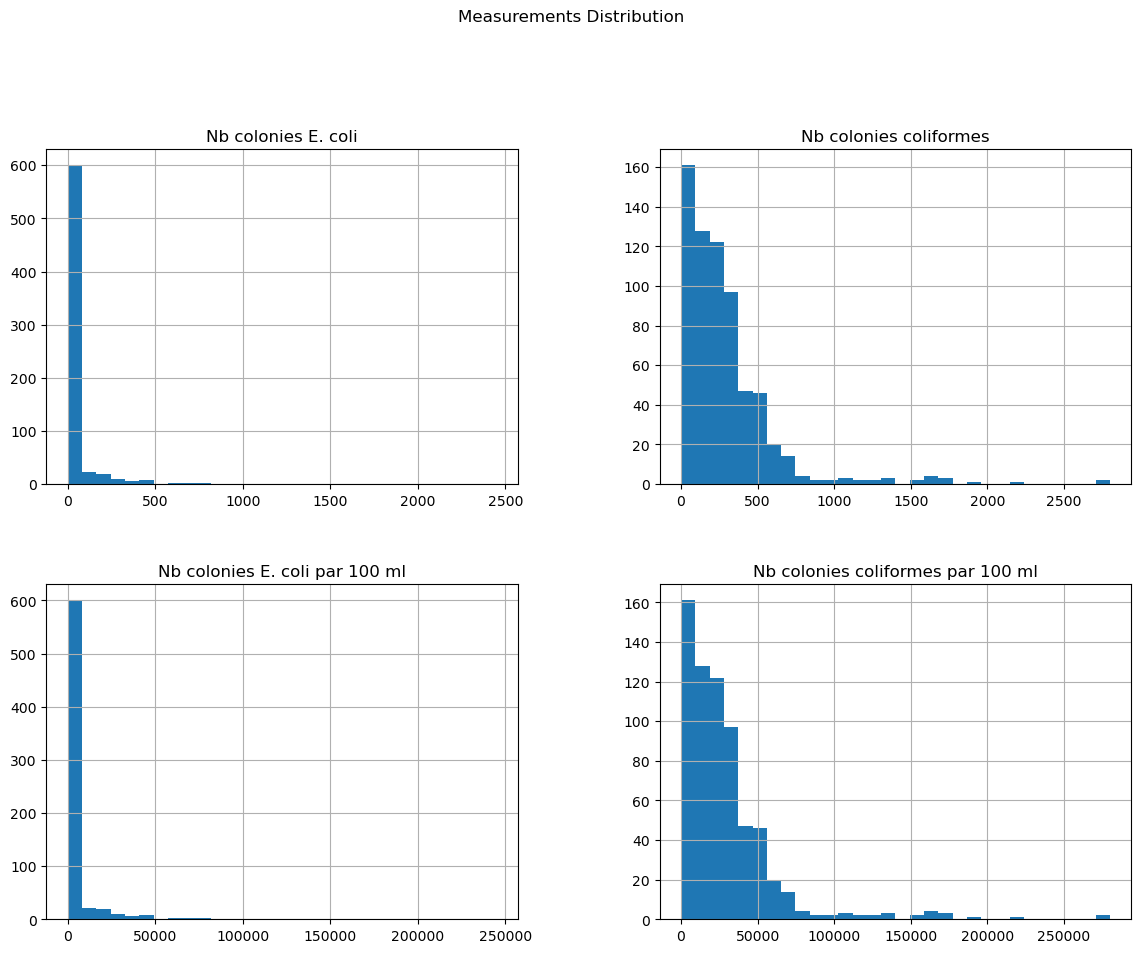

In [11]:
cols_measurements = [
    'Nb colonies E. coli',
    'Nb colonies coliformes'
]
cols_measurements_per_100mL = [
    'Nb colonies E. coli par 100 ml',
    'Nb colonies coliformes par 100 ml'
]

df[cols_measurements + cols_measurements_per_100mL].hist(figsize=(14, 10), bins=30)
plt.suptitle("Measurements Distribution", y=1.02);

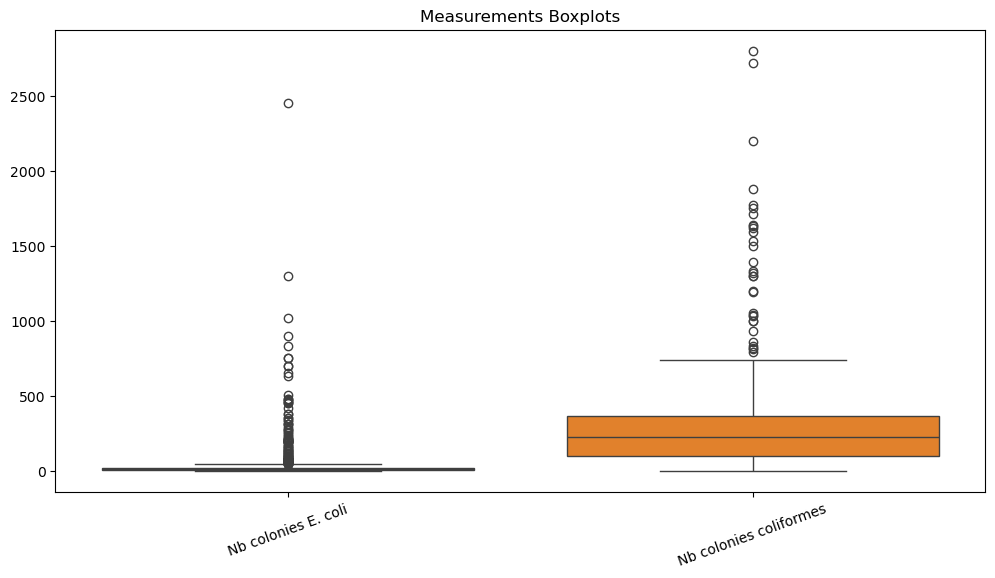

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_measurements])
plt.xticks(rotation=20)
plt.title("Measurements Boxplots");

Many outliers...

After filtering out the outliers (above `18` for the E. coli colonies count and above `696` for the coliform colonies count:

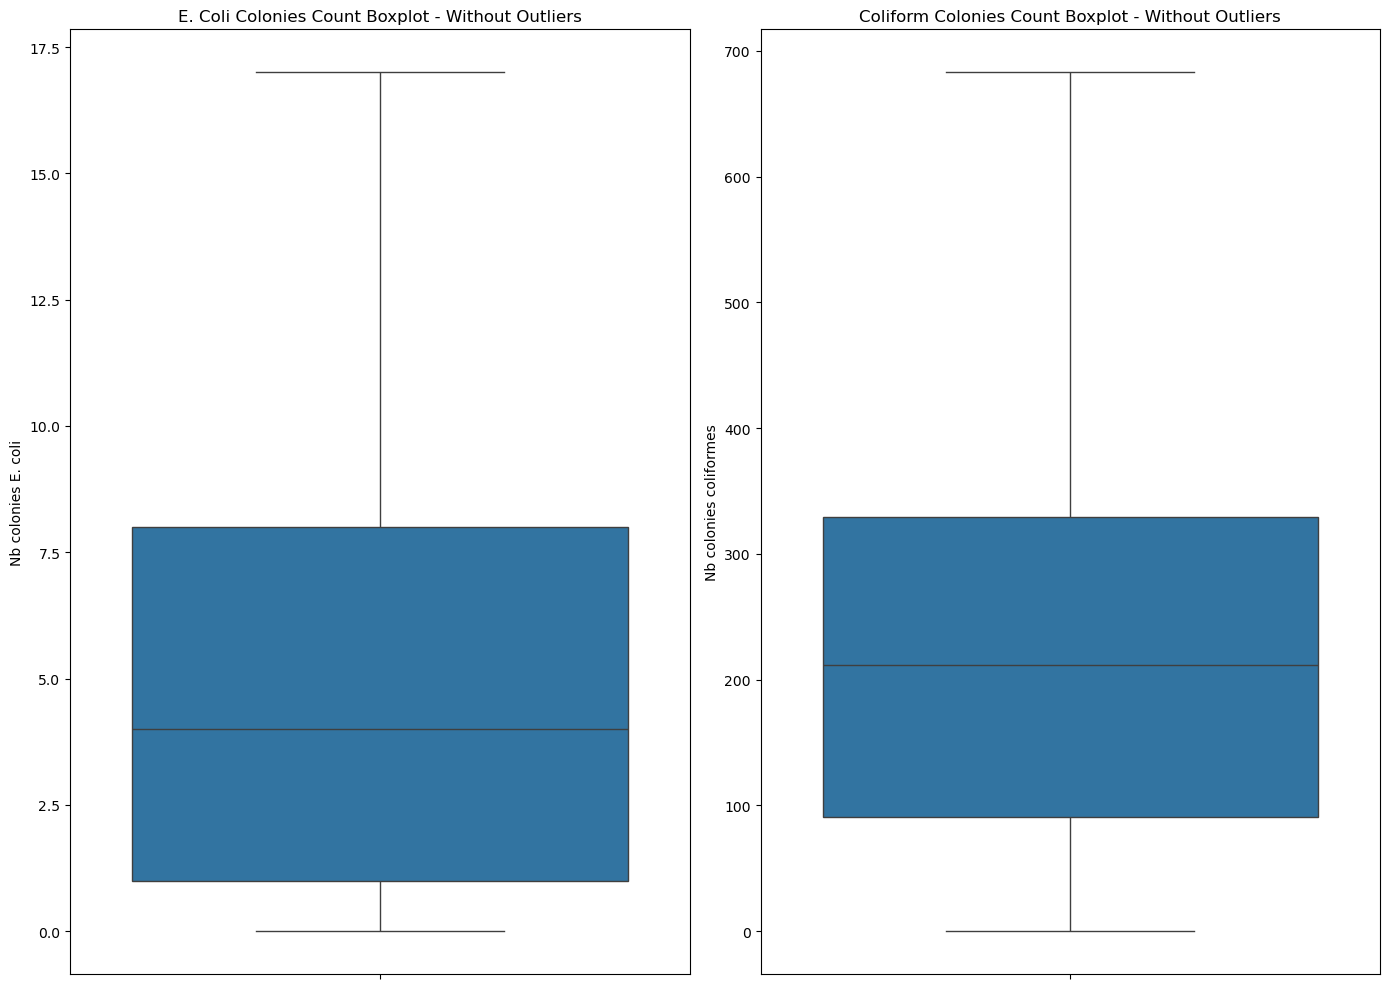

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df[df['Nb colonies E. coli'] < 18]['Nb colonies E. coli'], ax=axes[0])
#plt.xticks(rotation=20)
axes[0].set_title("E. Coli Colonies Count Boxplot - Without Outliers")

sns.boxplot(data=df[df['Nb colonies coliformes'] < 696]['Nb colonies coliformes'], ax=axes[1])
#plt.xticks(rotation=20)
axes[1].set_title("Coliform Colonies Count Boxplot - Without Outliers")

plt.tight_layout();

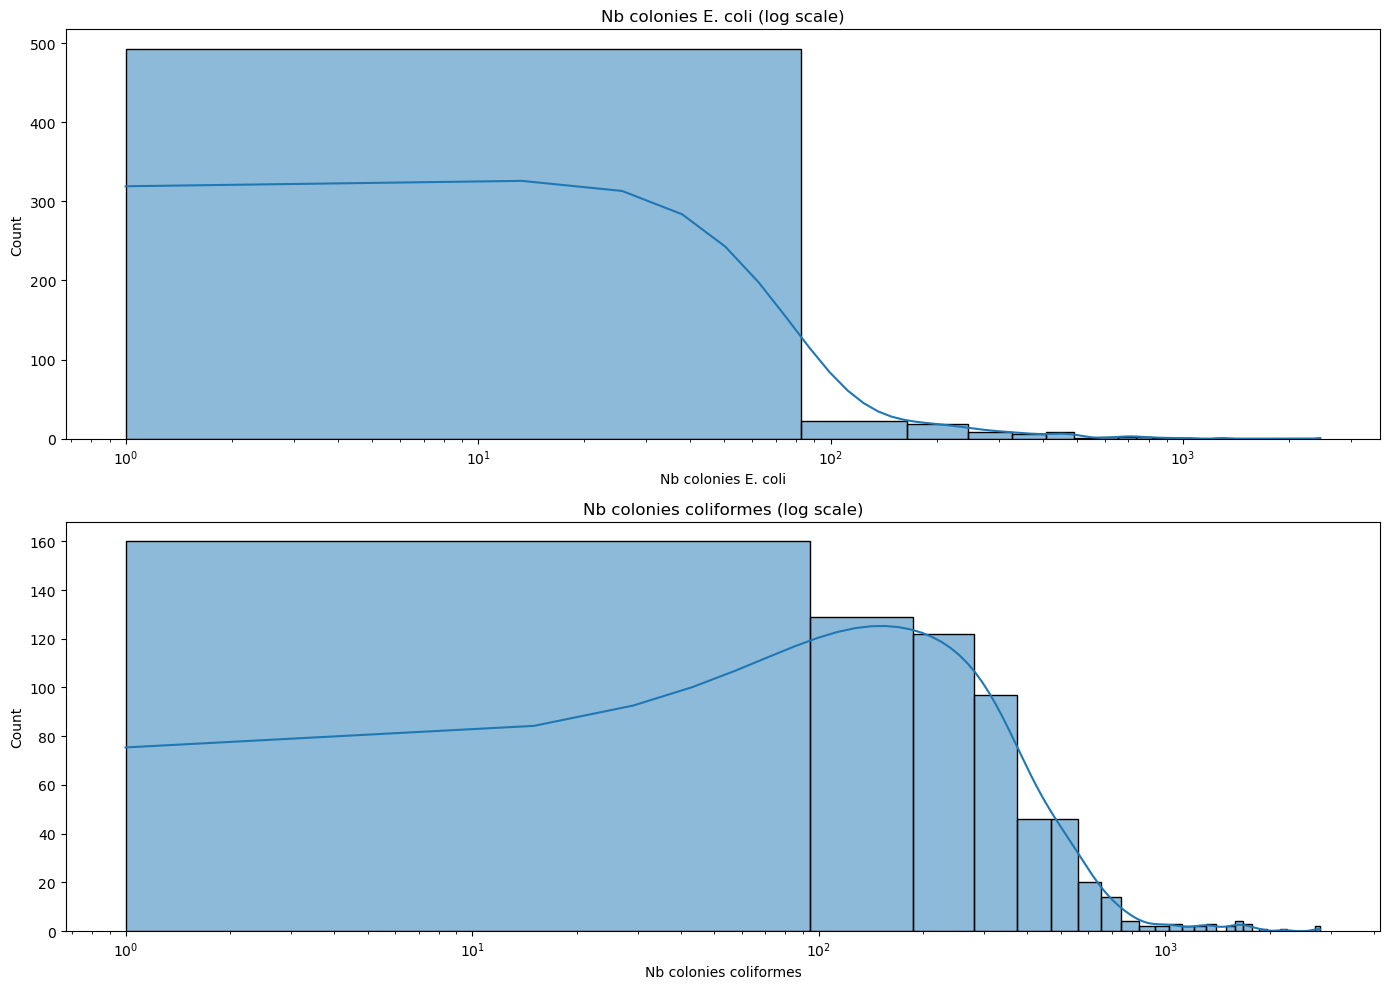

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_measurements):
    x = df[col].dropna()
    x = x[x > 0]  # to avoid log(0)
    
    sns.histplot(x, bins=30, kde=True, ax=axes[i])
    axes[i].set_xscale('log')
    axes[i].set_title(col + " (log scale)")

plt.tight_layout();

### 3.2. Analysis By River

In [15]:
rivers = np.unique(df['Rivière'])
rivers

array(['Baie de Montreux Lac', 'Baie de Montreux Rivière', 'Bief',
       'Boiron de Morges', 'Boiron de Nyon', 'Chamberonne', 'Cossy',
       'Morges', 'Mèbre', 'Paudèze', 'Plage de Préverenges', 'Sorge',
       'Tuyaux EC/EU', 'Venoge', 'Veveyse', 'Vuachère'], dtype=object)

In [16]:
df.groupby('Rivière').agg({
    'Nb colonies E. coli':'mean',
    'Nb colonies coliformes':'mean'
}).sort_values('Nb colonies E. coli')

,Nb colonies E. coli,Nb colonies coliformes
Rivière,,
Baie de Montreux Lac,0.84,44.37
Plage de Préverenges,1.14,83.76
Baie de Montreux Rivière,3.02,59.79
Veveyse,5.36,155.86
Boiron de Nyon,7.62,284.62
Morges,7.76,238.10
Cossy,10.71,599.94
Boiron de Morges,10.74,358.85
Sorge,11.83,82.00


In [76]:
stats = df.groupby('Rivière')[cols_measurements].describe()

sem = df.groupby('Rivière')[cols_measurements].sem()

for col in cols_measurements:
    stats[(col, 'sem')] = sem[col]

stats = stats.sort_values(
    by=('Nb colonies E. coli', '75%'),
    ascending=False
)

stats.style.background_gradient(
    cmap='viridis'
).format('{:.2f}')

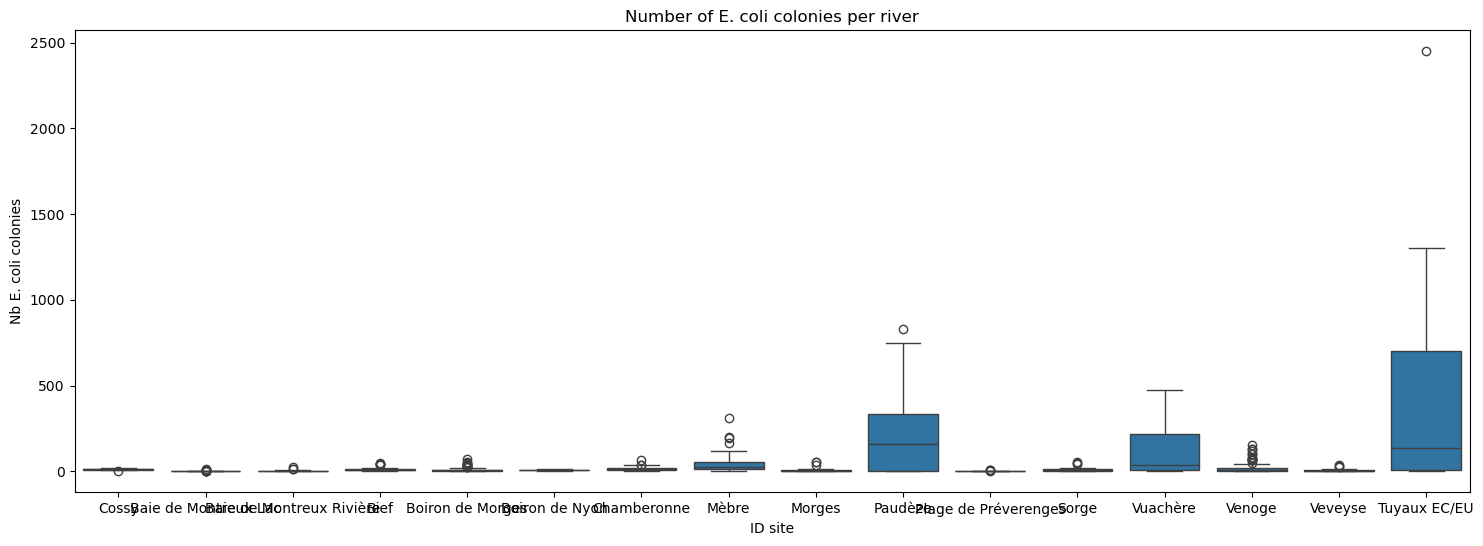

In [18]:
plt.figure(figsize=(18, 6))

sns.boxplot(
    data=df,
    x='Rivière',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per river")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

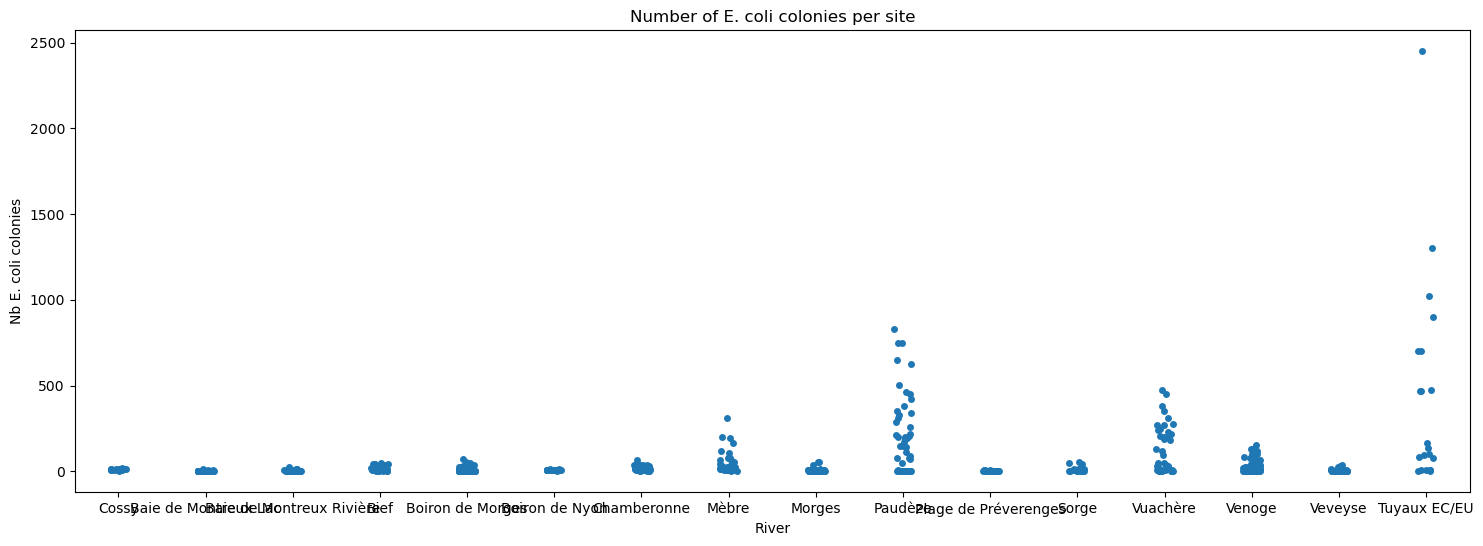

In [19]:
plt.figure(figsize=(18, 6))

sns.stripplot(
    data=df,
    x='Rivière',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("River")
plt.ylabel("Nb E. coli colonies");

In [20]:
def plotByField(data, field, column, plotType):
    fieldValues = sorted(data[field].dropna().unique())

    ncols = 4
    nrows = math.ceil(len(fieldValues) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows)
    )

    axes = axes.flatten()

    for ax, fld in zip(axes, fieldValues):
        data_field = df.loc[
            data[field] == fld,
            column
        ].dropna()
    
        if plotType == "boxplot":
            sns.boxplot(
                y=data_field,
                ax=ax
            )
        elif plotType == "stripplot":
            sns.stripplot(
                y=data_field,
                ax=ax,
                size=3,
                alpha=0.5
            )
    
        ax.set_title(fld)
        ax.set_ylabel(column)
        ax.set_xlabel("")
    
    # Hide unused cells
    for ax in axes[len(fieldValues):]:
        ax.set_visible(False)
    
    plt.tight_layout()

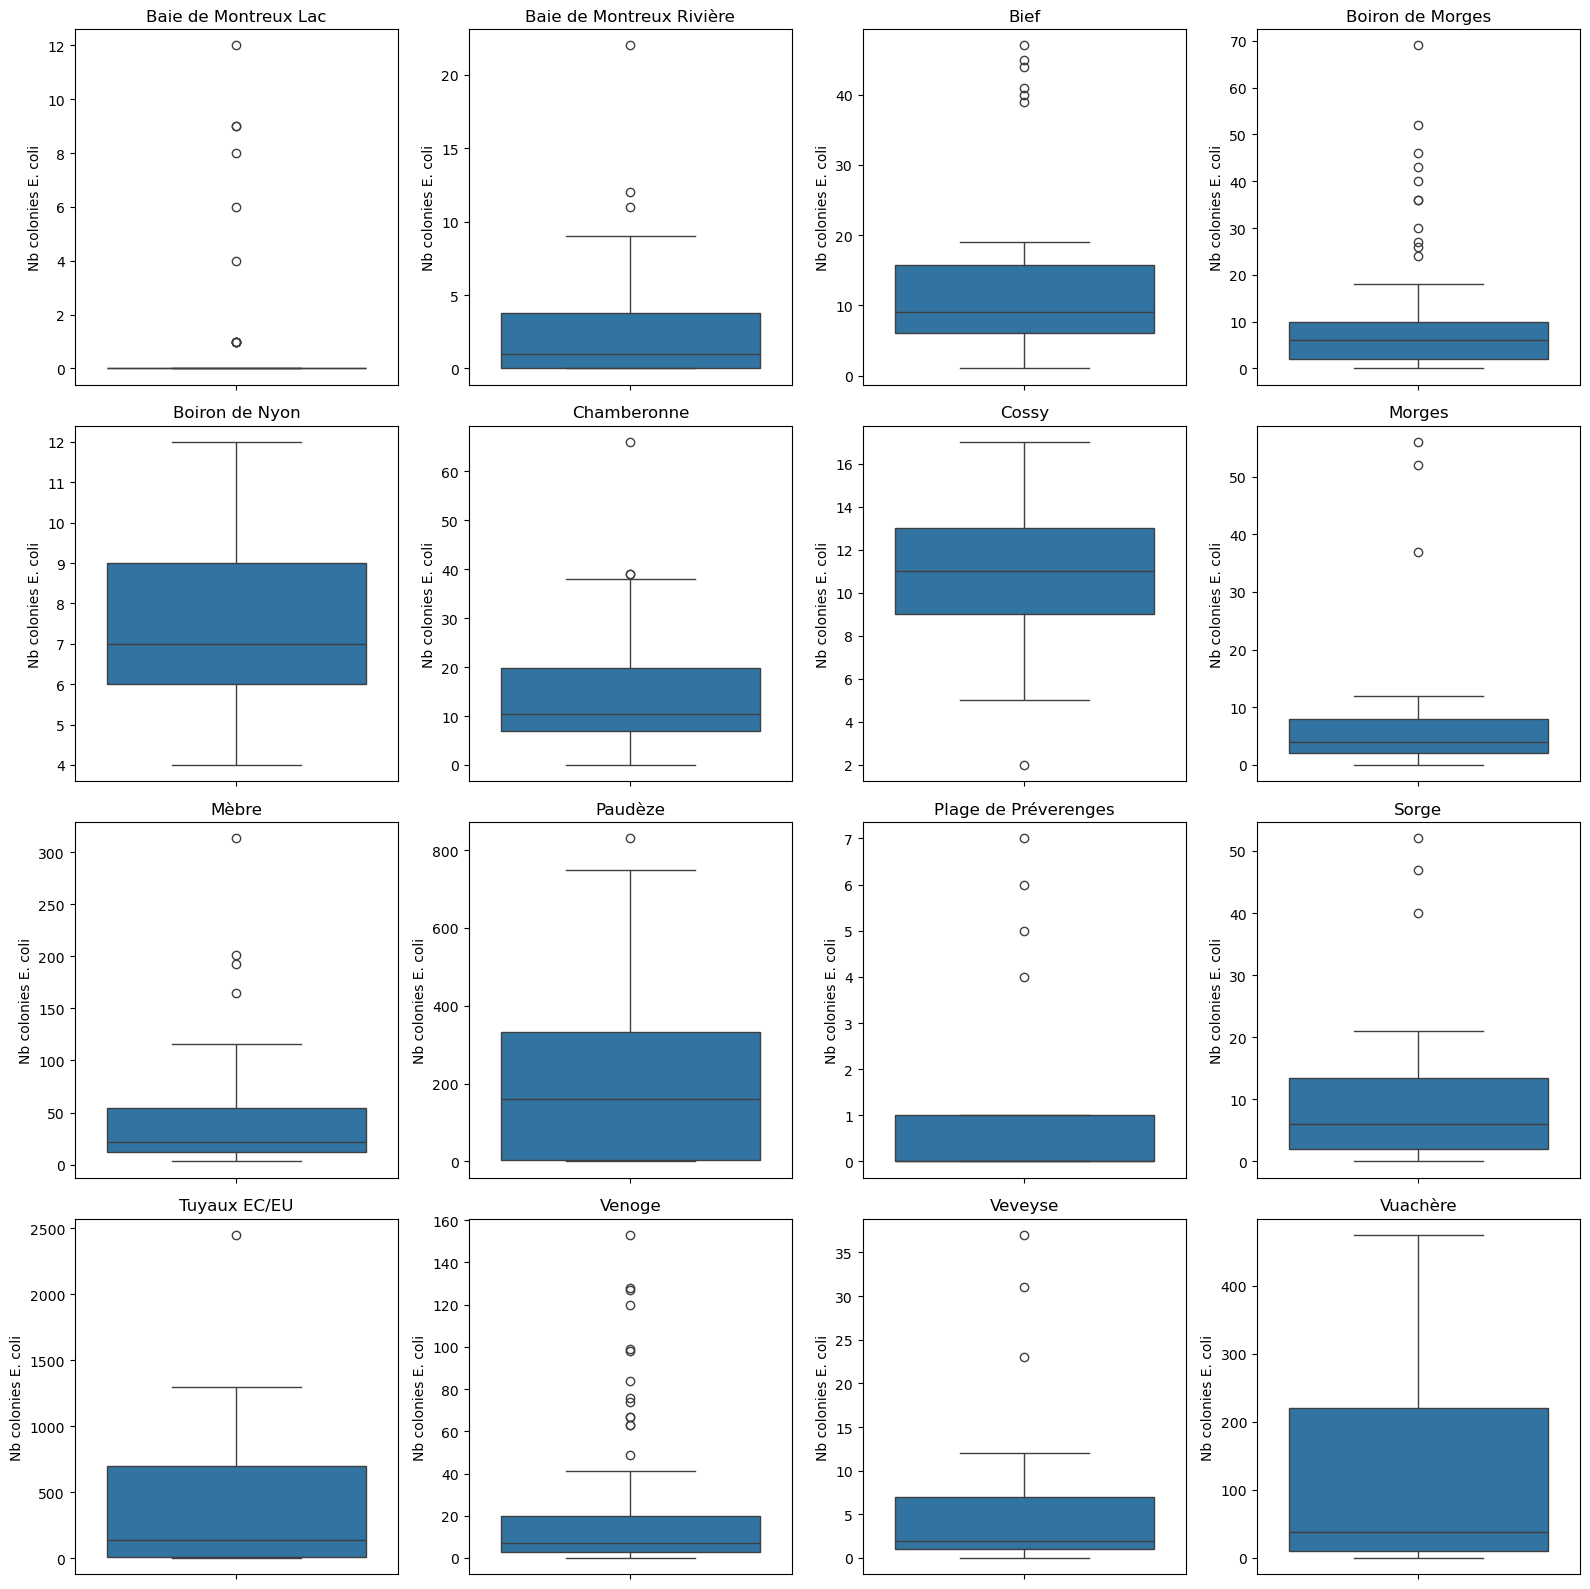

In [21]:
plotByField(df, "Rivière", "Nb colonies E. coli", "boxplot")

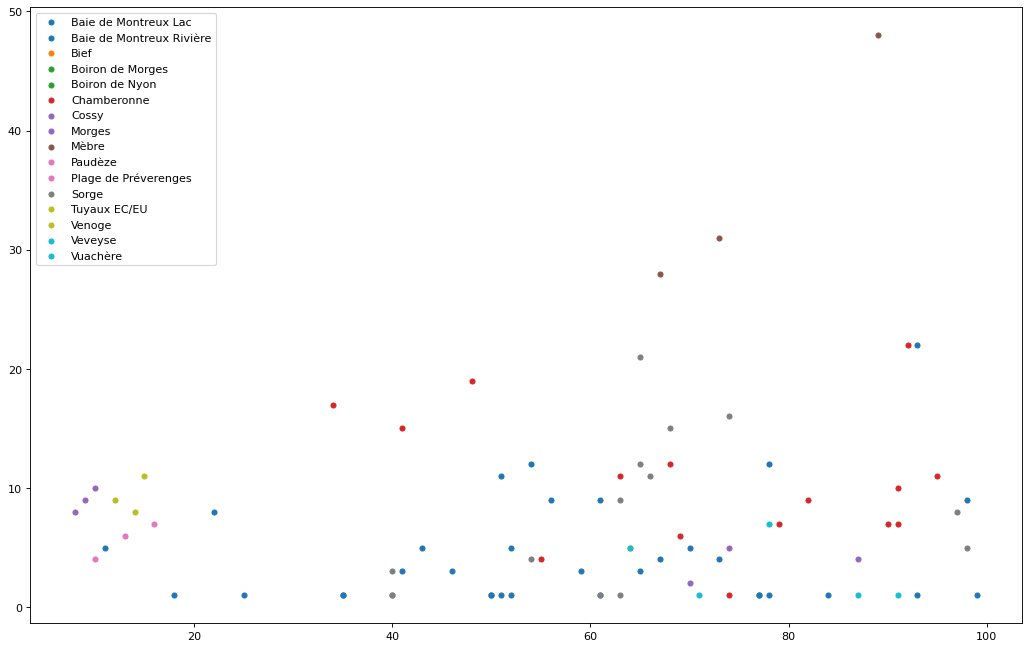

In [33]:
colors = [plt.cm.tab10(i/float(len(rivers)-1)) for i in range(len(rivers))]

df2 = df[(df['Nb colonies E. coli'] > 0) & (df['Nb colonies E. coli'] < 100) & (df['Nb colonies coliformes'] < 100) & (df['Nb colonies coliformes'] > 0)]

plt.figure(figsize=(16, 10), dpi= 80, facecolor='w', edgecolor='k')

for i, river in enumerate(rivers):
    plt.scatter('Nb colonies coliformes', 'Nb colonies E. coli', 
                data=df2.loc[df2['Rivière']==river, :], 
                s=20, color=colors[i], label=str(river))

plt.legend();

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_85274/1408856043.py:4: UserWarning: 
The palette list has fewer values (7) than needed (16) and will cycle, which may produce an uninterpretable plot.
  ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='Rivière', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)


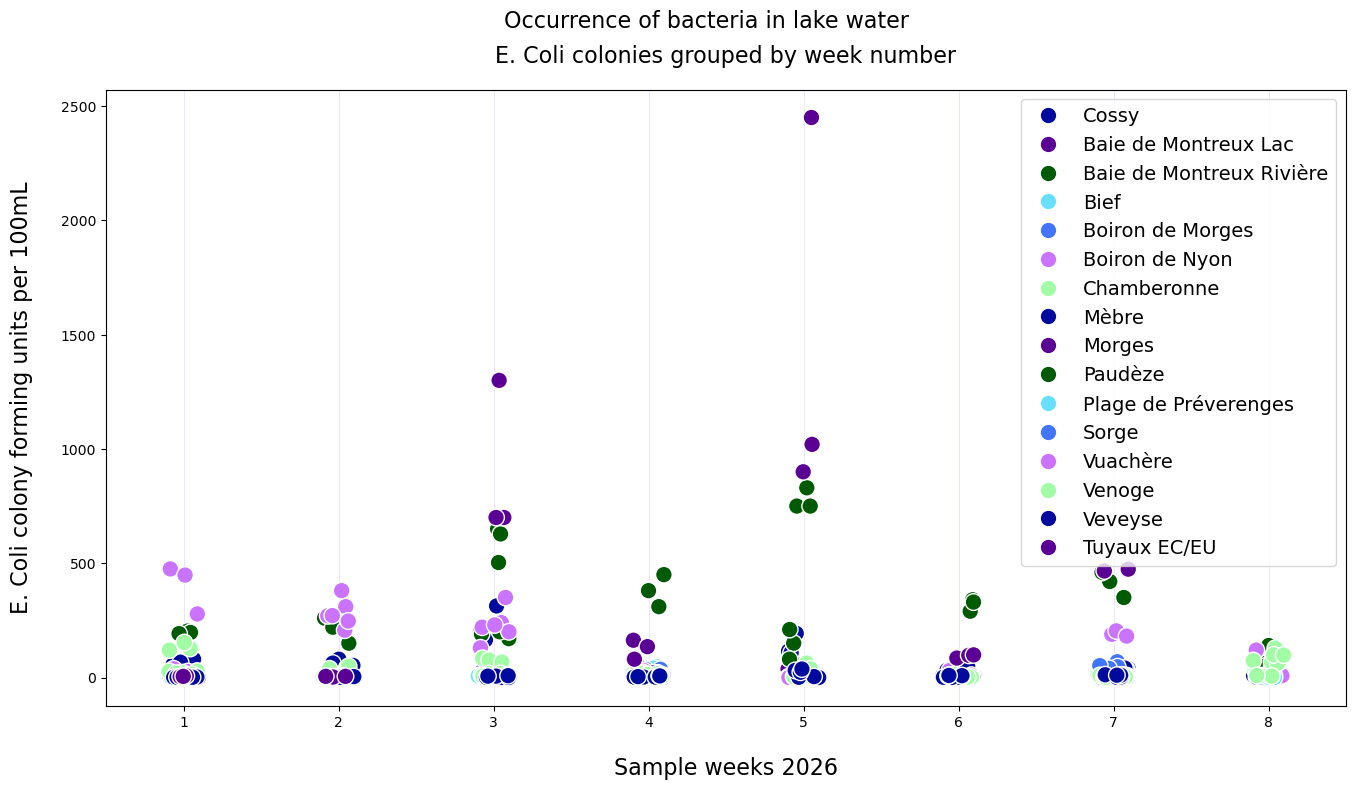

In [34]:
colors = ['#000A9C', '#5B0094', '#005903', '#68DFFC', '#4275FF', '#C973FF', '#A2FCA5']
fig, ax = plt.subplots(figsize=(16,8))

ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='Rivière', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel("E. Coli colony forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in lake water" , fontsize=16, family='sans')
plt.title("E. Coli colonies grouped by week number", fontsize=16, family='sans', y=1.03)
ax.legend(loc='upper right', fontsize=14);

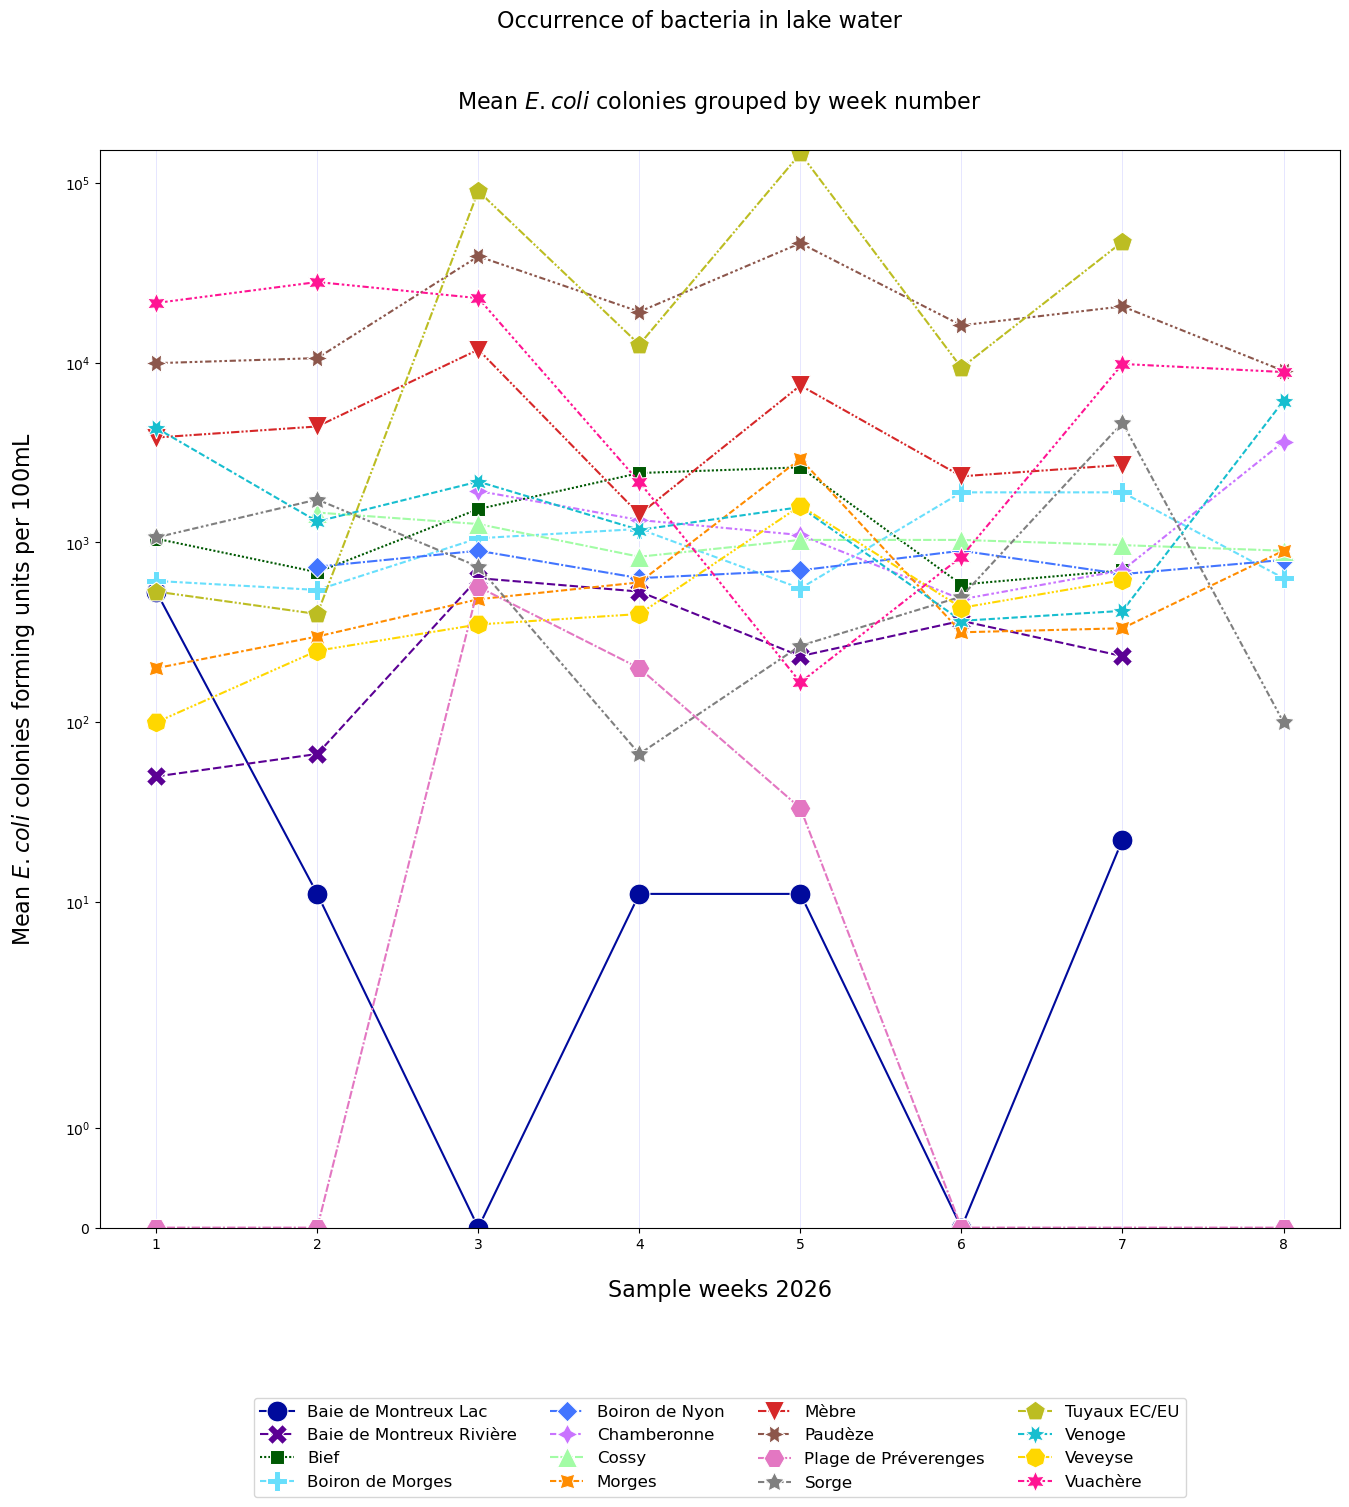

In [75]:
colors = [
    '#000A9C',  # dark blue
    '#5B0094',  # purple
    '#005903',  # dark green
    '#68DFFC',  # cyan
    '#4275FF',  # blue
    '#C973FF',  # light purple
    '#A2FCA5',  # light green
    '#FF8C00',  # orange
    '#D62728',  # red
    '#8C564B',  # brown
    '#E377C2',  # pink
    '#7F7F7F',  # grey
    '#BCBD22',  # olive
    '#17BECF',  # teal
    '#FFD700',  # gold
    '#FF1493'   # deep pink
]
fig, ax = plt.subplots(figsize=(16,14))

df_mean = (
    df.groupby(['Semaine', 'Rivière'], as_index=False)
      ['Nb colonies E. coli par 100 ml']
      .mean()
)

#df_mean_log = df_mean[df_mean['Nb colonies E. coli'] > 0]

#sns.scatterplot(
#    x='Semaine',
#    y='Nb colonies E. coli',
#    hue='Rivière',
#    data=df_mean, 
#    s=120,
#    style='Rivière',
#    palette=colors,
#    ax=ax
#)

sns.lineplot(
    x='Semaine',
    y="Nb colonies E. coli par 100 ml",
    hue='Rivière',
    data=df_mean,
    style='Rivière',
    markers=True,
    dashes=True,
    markersize=15,
    palette=colors,
    ax=ax
)

ax.set_yscale('symlog', linscale=1)
ax.set_ylim(bottom=0)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel(r"Mean $\it{E. coli}$ colonies forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in lake water" , fontsize=16, family='sans')
plt.title(r"Mean $\it{E. coli}$ colonies grouped by week number", fontsize=16, family='sans', y=1.03)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_85274/429775603.py:18: UserWarning: The palette list has more values (16) than needed (12), which may not be intended.
  sns.lineplot(


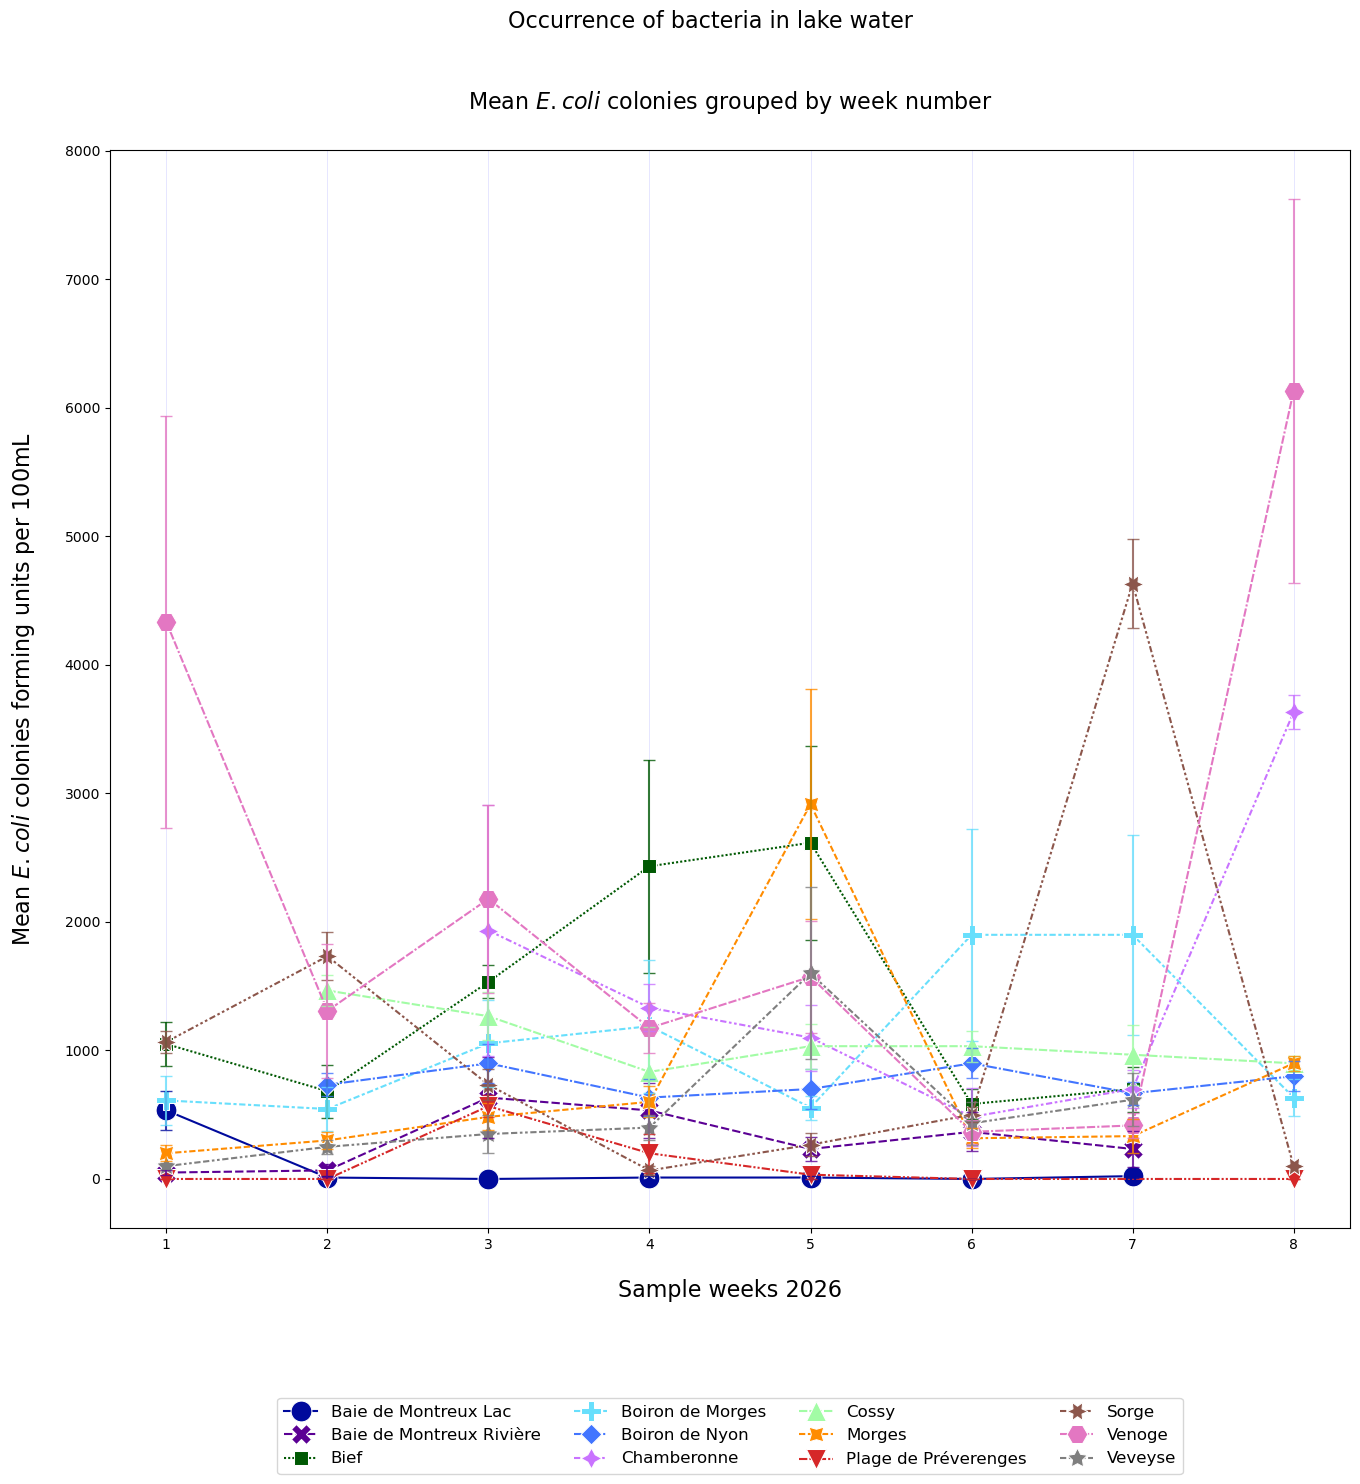

In [82]:
colors = [
    '#000A9C', '#5B0094', '#005903', '#68DFFC',
    '#4275FF', '#C973FF', '#A2FCA5', '#FF8C00',
    '#D62728', '#8C564B', '#E377C2', '#7F7F7F',
    '#BCBD22', '#17BECF', '#FFD700', '#FF1493'
]

fig, ax = plt.subplots(figsize=(16, 14))

df_wo_high_values = df[(df['Rivière'] != 'Tuyaux EC/EU') & (df['Rivière'] != 'Paudèze') & (df['Rivière'] != 'Vuachère')  & (df['Rivière'] != 'Mèbre')]

df_stats = (
    df_wo_high_values.groupby(['Semaine', 'Rivière'])['Nb colonies E. coli par 100 ml']
      .agg(['mean', 'sem'])
      .reset_index()
)

sns.lineplot(
    x='Semaine',
    y='mean',
    hue='Rivière',
    data=df_stats,
    style='Rivière',
    markers=True,
    dashes=True,
    markersize=15,
    palette=colors,
    ax=ax
)

rivieres = df_stats['Rivière'].unique()

for i, riviere in enumerate(rivieres):
    subset = df_stats[df_stats['Rivière'] == riviere]

    ax.errorbar(
        subset['Semaine'],
        subset['mean'],
        yerr=subset['sem'],
        fmt='none',
        ecolor=colors[i],
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )

#ax.set_yscale('symlog', linscale=1)
#ax.set_ylim(bottom=0)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)

ax.set_xlabel(
    "Sample weeks 2026",
    size=16,
    labelpad=20
)

ax.set_ylabel(
    r"Mean $\it{E. coli}$ colonies forming units per 100mL",
    size=16,
    labelpad=20
)

plt.suptitle(
    "Occurrence of bacteria in lake water",
    fontsize=16,
    family='sans'
)

plt.title(
    r"Mean $\it{E. coli}$ colonies grouped by week number",
    fontsize=16,
    family='sans',
    y=1.03
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

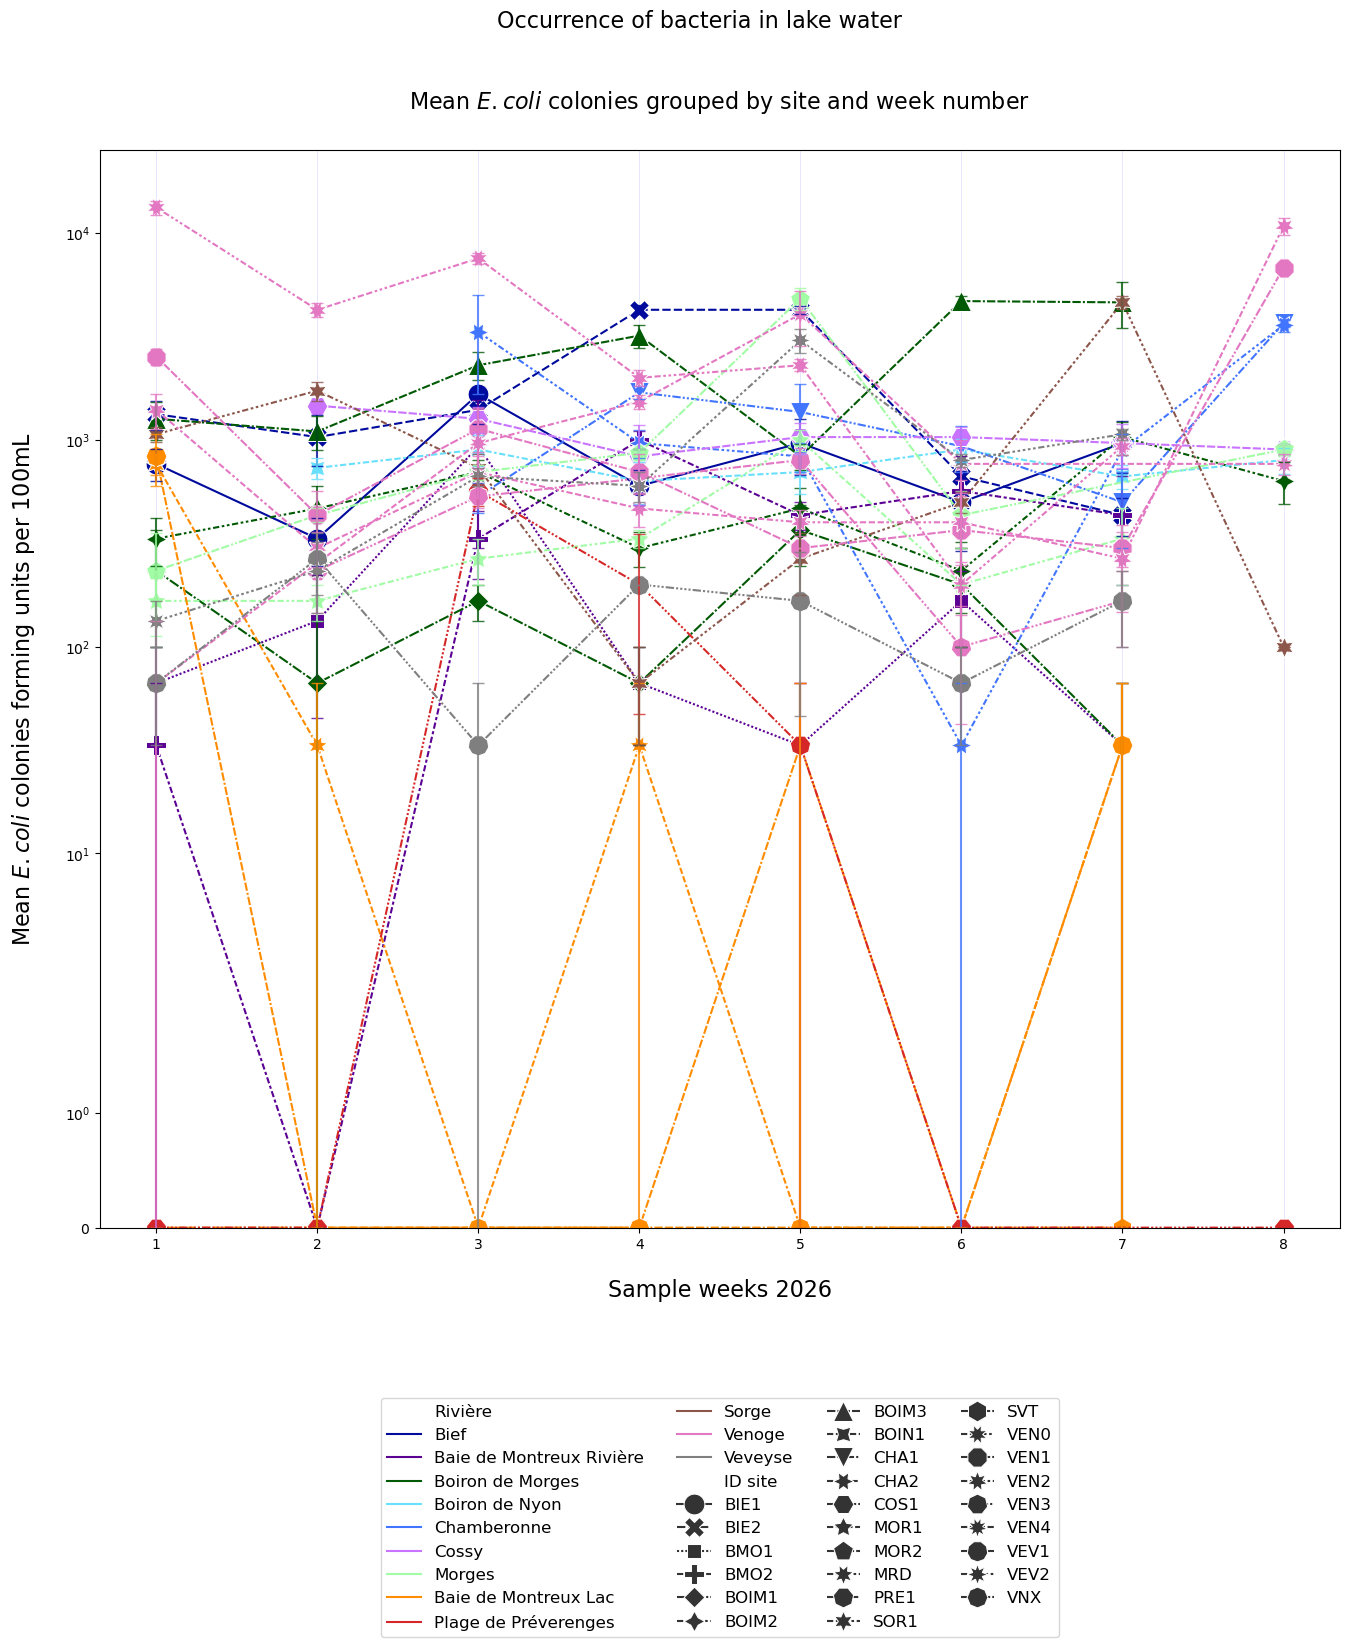

In [84]:
colors = [
    '#000A9C', '#5B0094', '#005903', '#68DFFC',
    '#4275FF', '#C973FF', '#A2FCA5', '#FF8C00',
    '#D62728', '#8C564B', '#E377C2', '#7F7F7F',
    '#BCBD22', '#17BECF', '#FFD700', '#FF1493'
]

fig, ax = plt.subplots(figsize=(16, 14))

df_wo_high_values = df[
    ~df['Rivière'].isin([
        'Tuyaux EC/EU',
        'Paudèze',
        'Vuachère',
        'Mèbre'
    ])
]

# Mean + SEM for each SITE, each week
df_stats = (
    df_wo_high_values
    .groupby(['Semaine', 'ID site', 'Rivière'])[
        'Nb colonies E. coli par 100 ml'
    ]
    .agg(['mean', 'sem'])
    .reset_index()
)

# One color per river
rivieres = df_stats['Rivière'].unique()

river_colors = {
    riviere: colors[i]
    for i, riviere in enumerate(rivieres)
}

sns.lineplot(
    data=df_stats,
    x='Semaine',
    y='mean',
    hue='Rivière',       # same color for sites of same river
    style='ID site',     # different marker/style for each site
    markers=True,
    dashes=True,
    markersize=15,
    palette=river_colors,
    ax=ax
)

for site, subset in df_stats.groupby('ID site'):

    riviere = subset['Rivière'].iloc[0]

    ax.errorbar(
        subset['Semaine'],
        subset['mean'],
        yerr=subset['sem'],
        fmt='none',
        ecolor=river_colors[riviere],
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )

ax.xaxis.grid(
    which="major",
    color='b',
    linewidth=0.7,
    alpha=0.1
)

ax.set_xlabel(
    "Sample weeks 2026",
    size=16,
    labelpad=20
)

ax.set_ylabel(
    r"Mean $\it{E. coli}$ colonies forming units per 100mL",
    size=16,
    labelpad=20
)

plt.suptitle(
    "Occurrence of bacteria in lake water",
    fontsize=16,
    family='sans'
)

plt.title(
    r"Mean $\it{E. coli}$ colonies grouped by site and week number",
    fontsize=16,
    family='sans',
    y=1.03
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

In [103]:
high_rivers = ['Vuachère', 'Venoge', 'Paudèze', 'Mèbre']
tuyaux = ['Tuyaux EC/EU']
lakes = ['Baie de Montreux Lac']

other_rivers = [
    r for r in df['Rivière'].dropna().unique()
    if r not in high_rivers + tuyaux + lakes
]

In [97]:
def plot_ecoli_by_site(data, title, colors):
    fig, ax = plt.subplots(figsize=(16, 14))

    df_stats = (
        data
        .groupby(['Semaine', 'ID site', 'Rivière'])[
            'Nb colonies E. coli par 100 ml'
        ]
        .agg(['mean', 'sem'])
        .reset_index()
    )

    rivieres = df_stats['Rivière'].unique()

    river_colors = {
        riviere: colors[i]
        for i, riviere in enumerate(rivieres)
    }

    sns.lineplot(
        data=df_stats,
        x='Semaine',
        y='mean',
        hue='Rivière',
        style='ID site',
        markers=True,
        dashes=True,
        markersize=15,
        palette=river_colors,
        ax=ax
    )

    for site, subset in df_stats.groupby('ID site'):
        riviere = subset['Rivière'].iloc[0]

        ax.errorbar(
            subset['Semaine'],
            subset['mean'],
            yerr=subset['sem'],
            fmt='none',
            ecolor=river_colors[riviere],
            elinewidth=1.5,
            capsize=4,
            alpha=0.8
        )

    ax.xaxis.grid(
        which="major",
        linewidth=0.7,
        alpha=0.1
    )

    ax.set_xlabel(
        "Sample weeks 2026",
        size=16,
        labelpad=20
    )

    ax.set_ylabel(
        r"Mean $\it{E. coli}$ colonies forming units per 100mL",
        size=16,
        labelpad=20
    )

    plt.suptitle(
        "Occurrence of bacteria in lake water",
        fontsize=16
    )

    plt.title(
        title,
        fontsize=16,
        y=1.03
    )

    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        fontsize=12
    )

    plt.show()

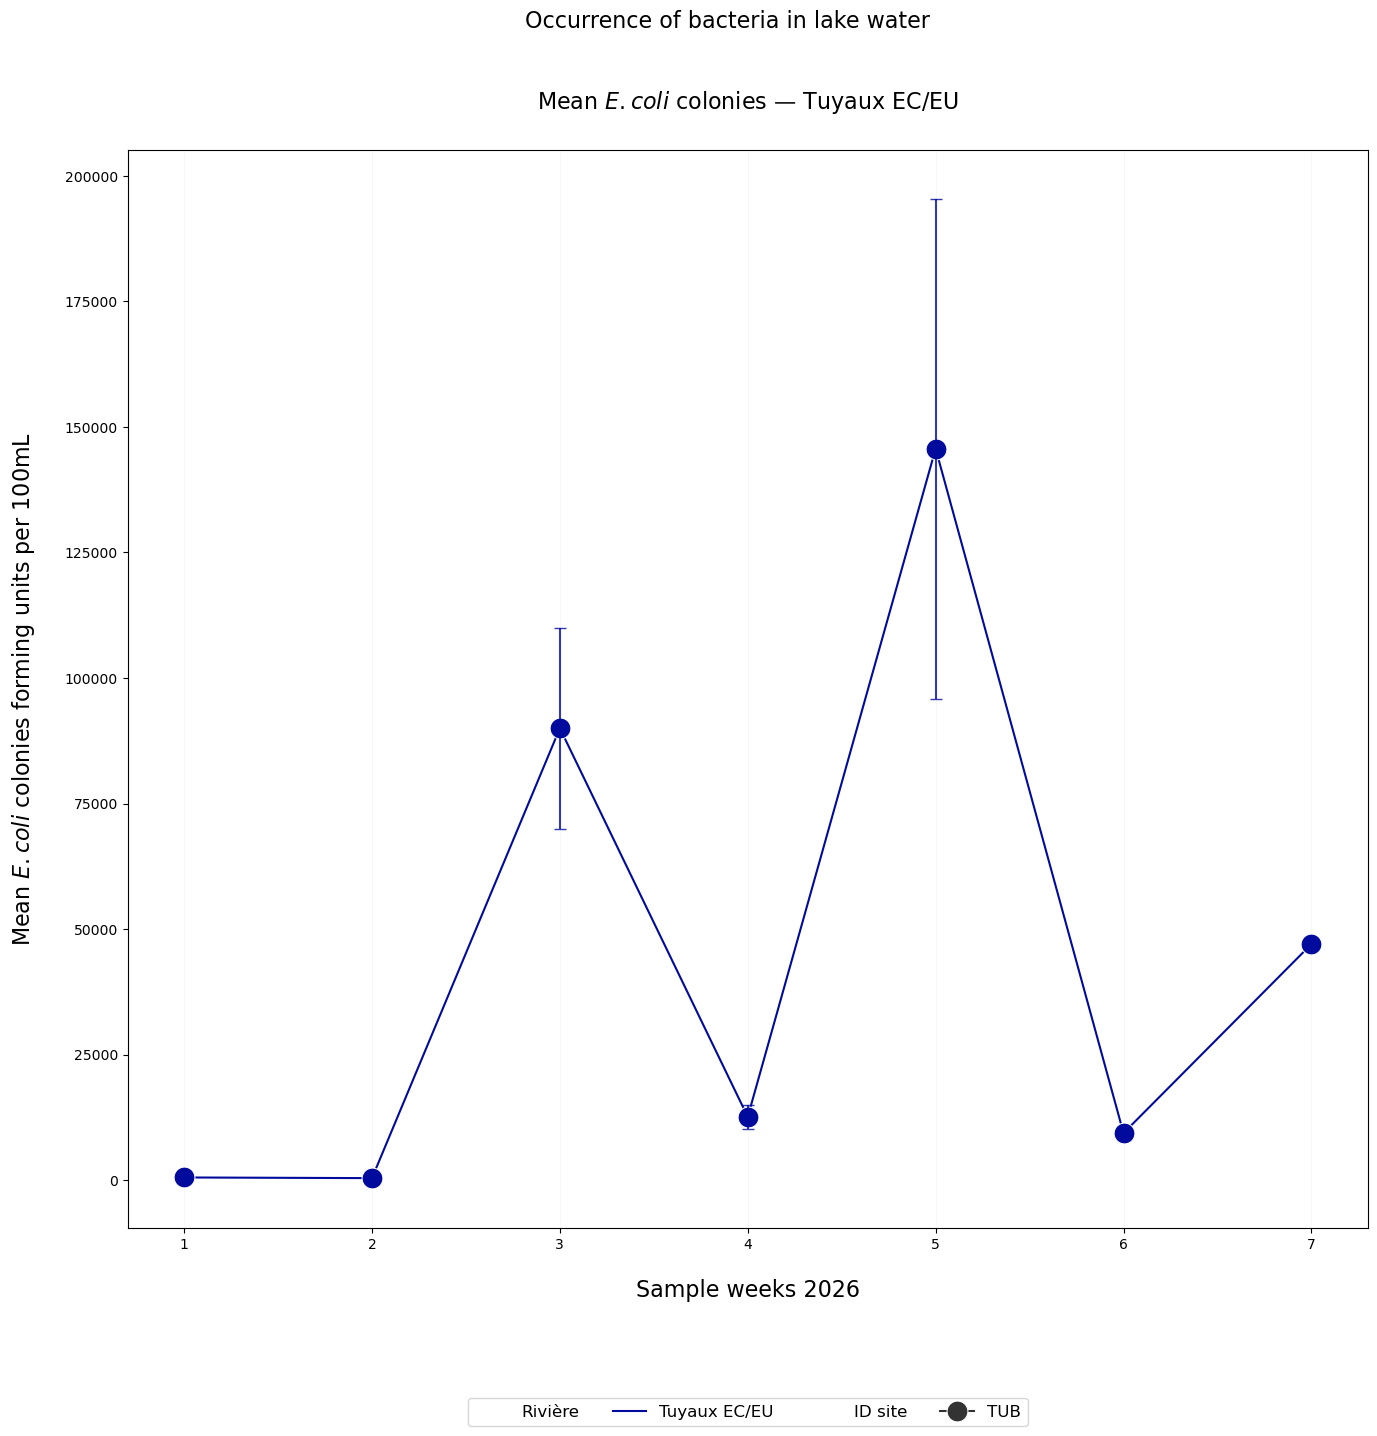

In [98]:
plot_ecoli_by_site(
    df[df['Rivière'] == 'Tuyaux EC/EU'],
    r"Mean $\it{E. coli}$ colonies — Tuyaux EC/EU",
    colors
)

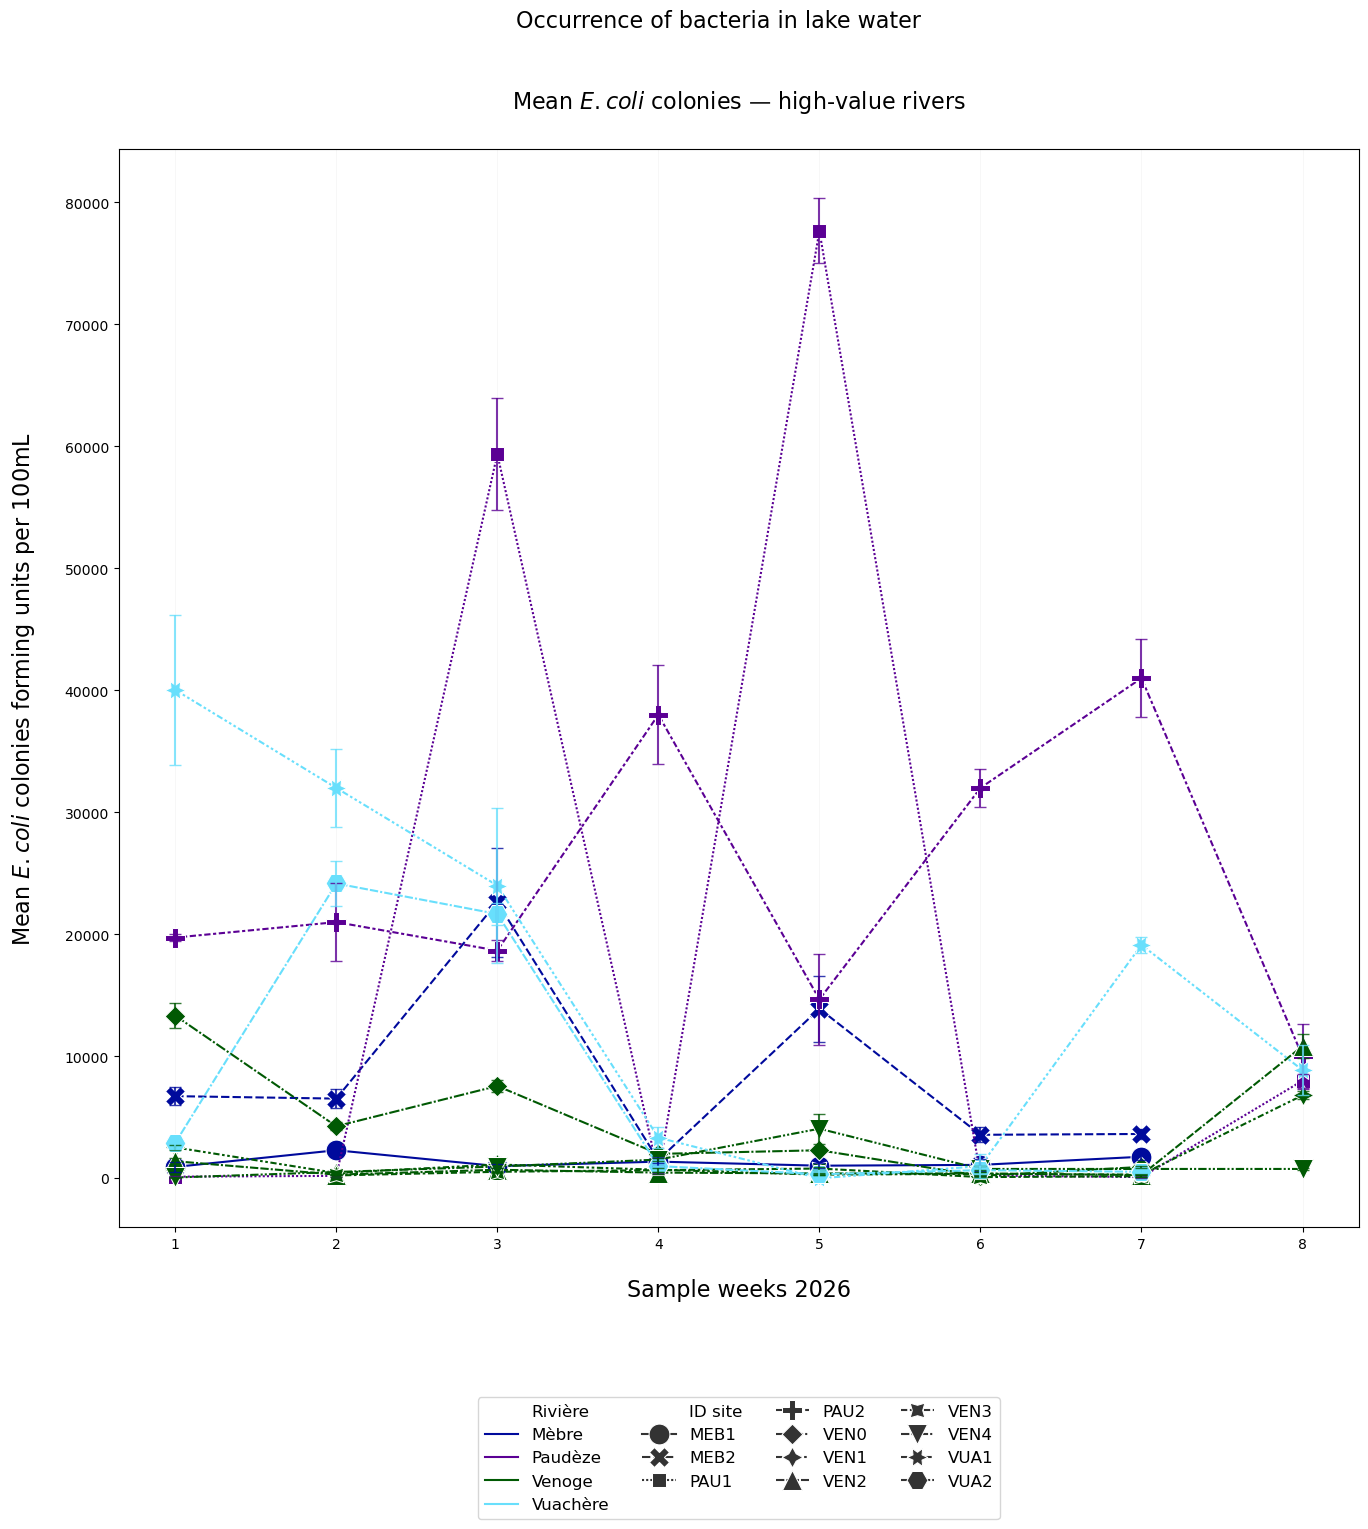

In [99]:
plot_ecoli_by_site(
    df[df['Rivière'].isin(high_rivers)],
    r"Mean $\it{E. coli}$ colonies — high-value rivers",
    colors
)

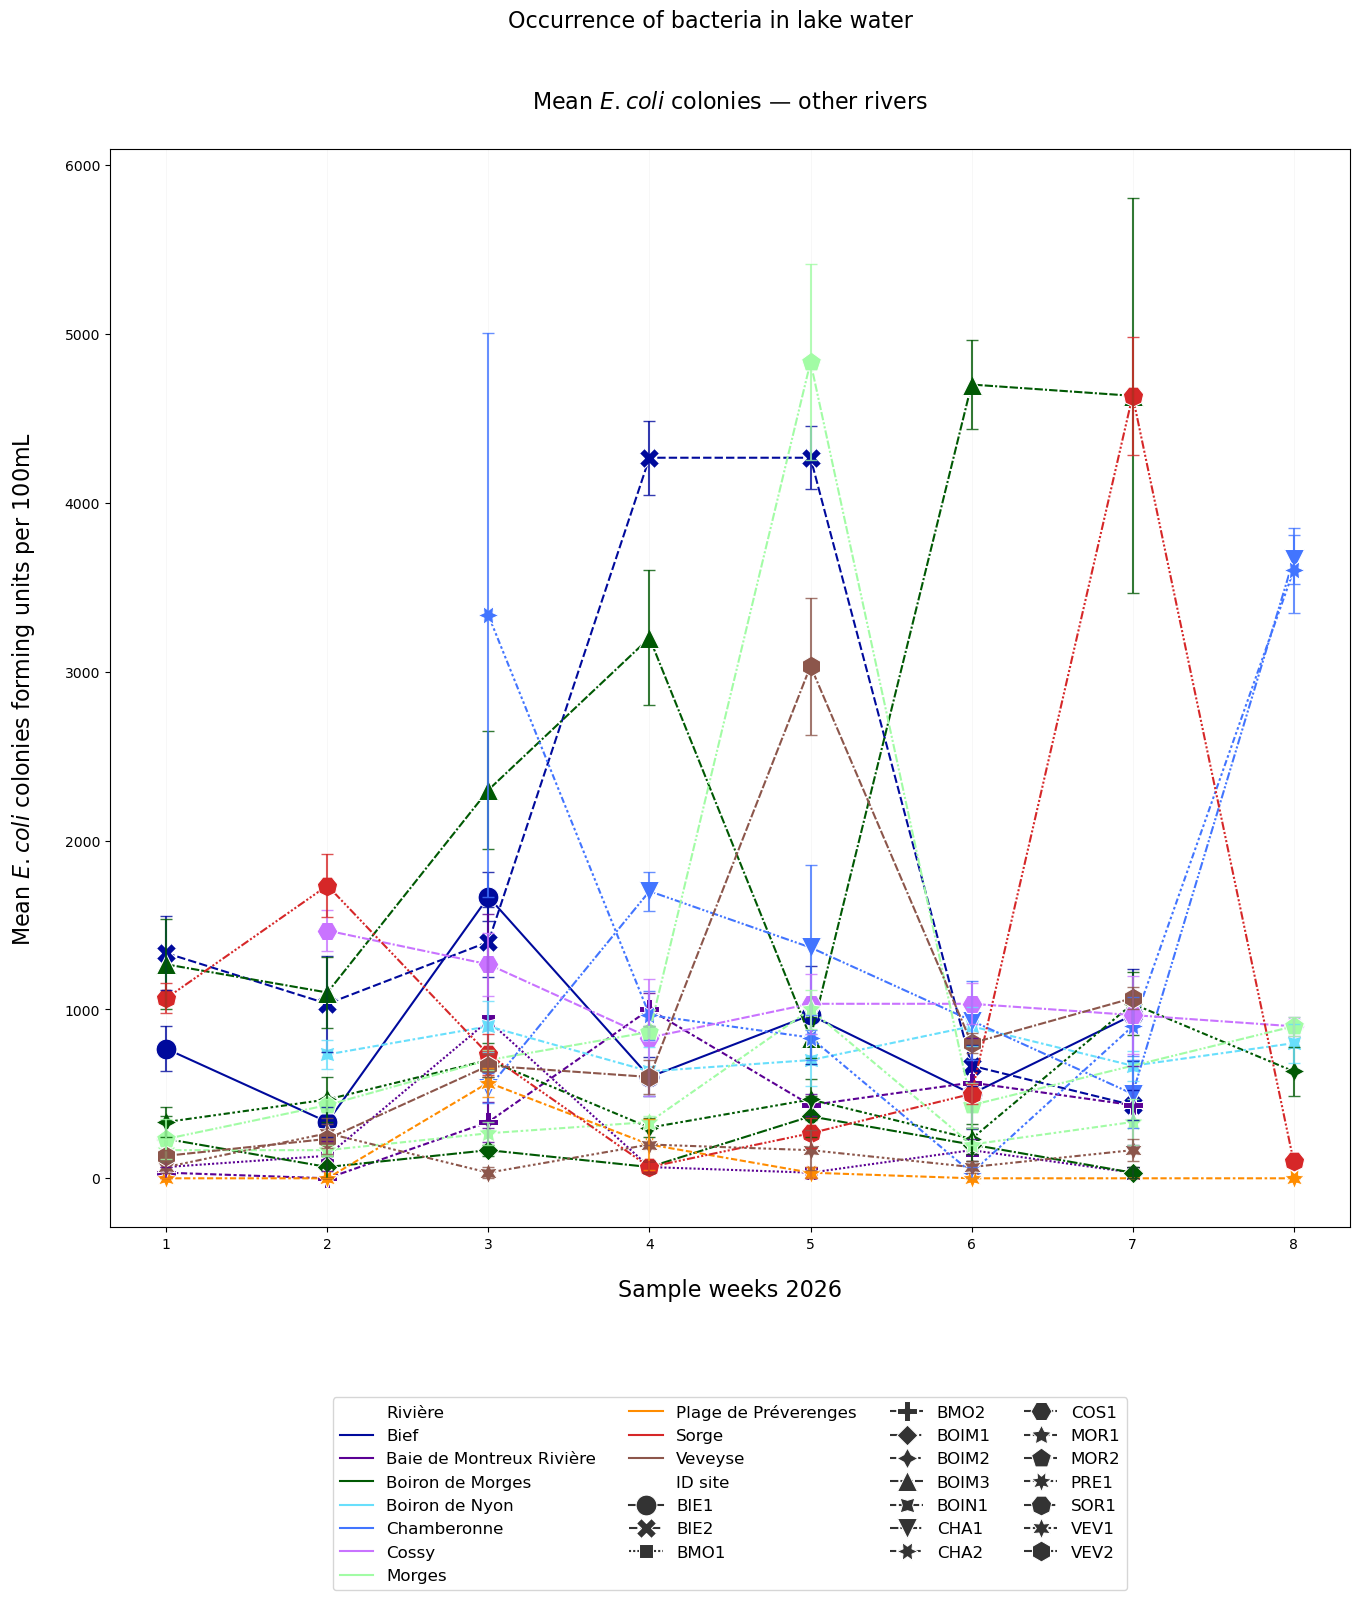

In [105]:
plot_ecoli_by_site(
    df[~df['Rivière'].isin(high_rivers + tuyaux + lakes)],
    r"Mean $\it{E. coli}$ colonies — other rivers",
    colors
)

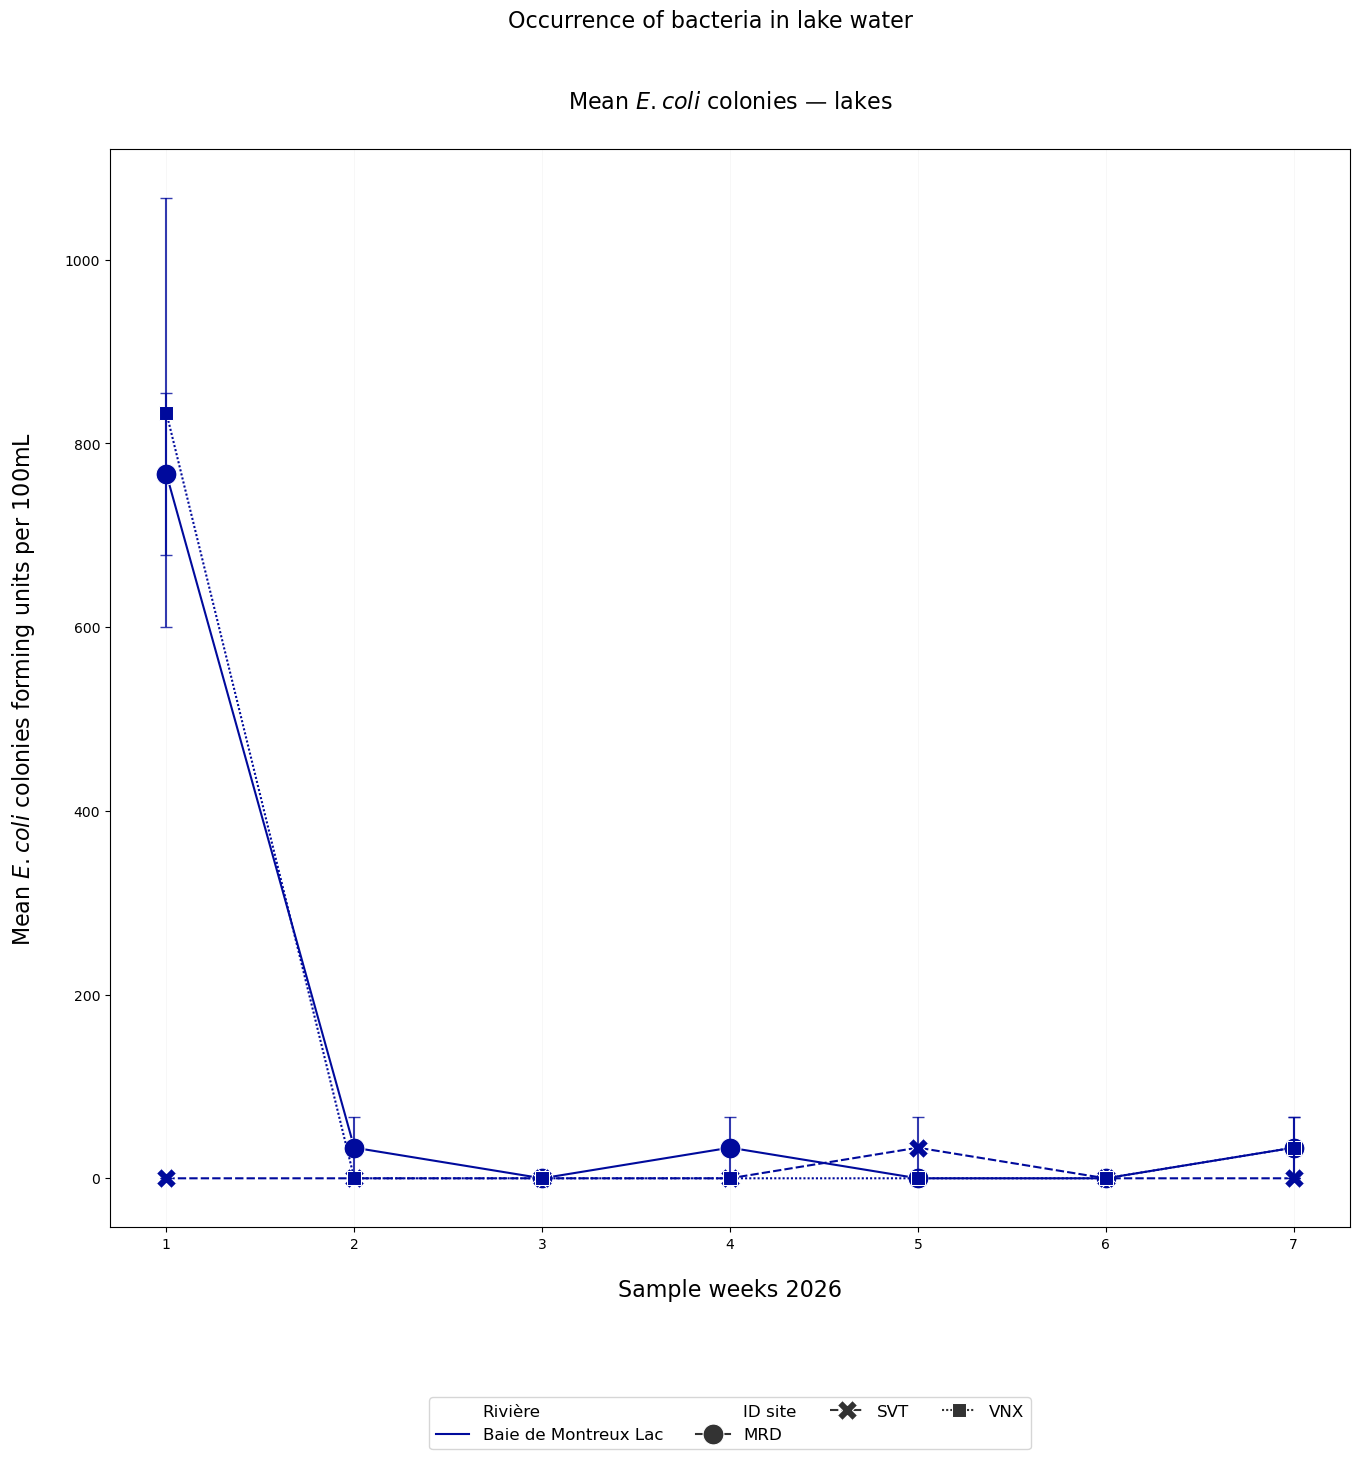

In [104]:
plot_ecoli_by_site(
    df[df['Rivière'].isin(lakes)],
    r"Mean $\it{E. coli}$ colonies — lakes",
    colors
)

### 3.3. Analysis By Site

In [23]:
df.groupby('ID site').agg({
    'Nb colonies E. coli':'mean',
    'Nb colonies coliformes':'mean'
}).sort_values('Nb colonies E. coli')

,Nb colonies E. coli,Nb colonies coliformes
ID site,,
SVT,0.05,21.24
PRE1,1.14,83.76
MRD,1.24,78.67
VNX,1.24,33.19
VEV1,1.38,147.10
BOIM1,1.60,355.20
BMO1,2.05,79.05
MOR1,3.52,226.29
VEN3,3.67,377.73


In [24]:
stats = df.groupby('ID site')[cols_measurements].describe()

stats = stats.sort_values(
    by=('Nb colonies E. coli', '75%'),
    ascending=False
)

stats.style.background_gradient(cmap='viridis').format('{:.2f}')

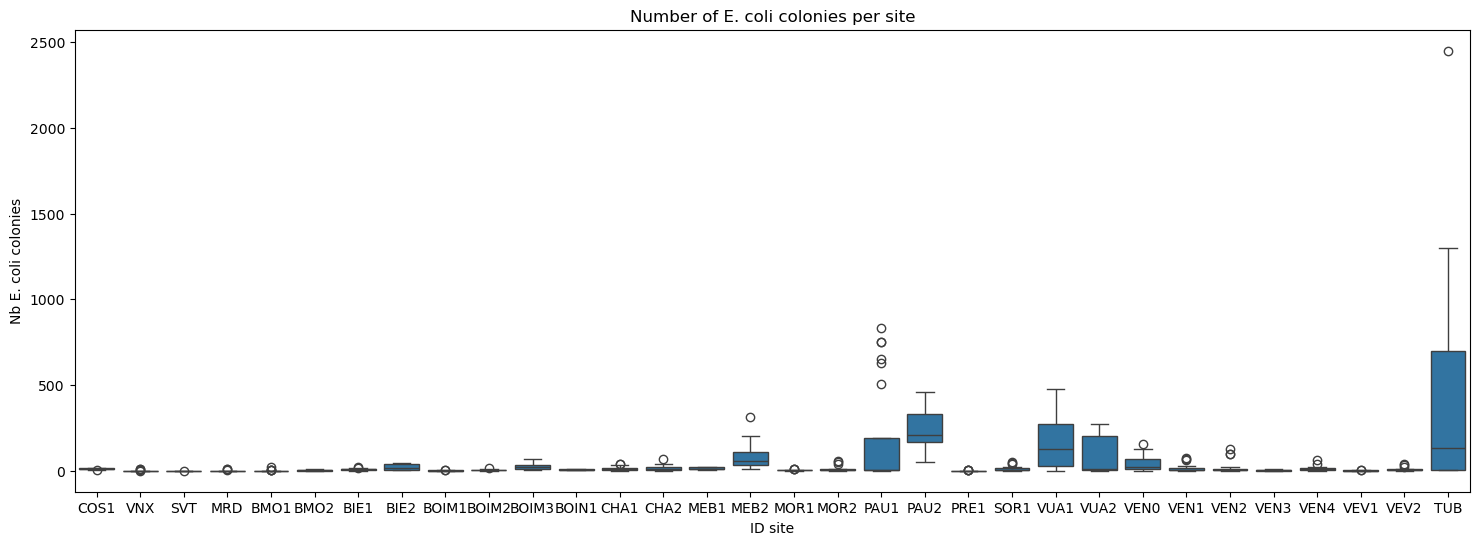

In [25]:
plt.figure(figsize=(18, 6))

sns.boxplot(
    data=df,
    x='ID site',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

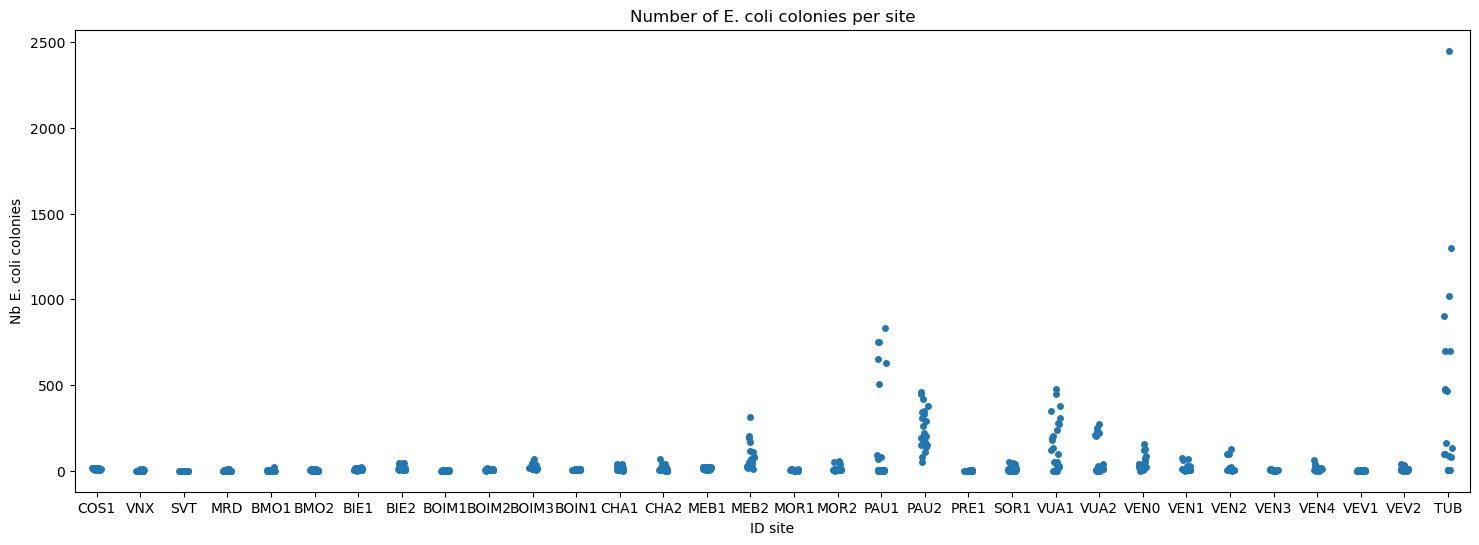

In [26]:
plt.figure(figsize=(18, 6))

sns.stripplot(
    data=df,
    x='ID site',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

In [27]:
def plotBySite(data, column, plotType):
    sites = sorted(data['ID site'].dropna().unique())

    ncols = 4
    nrows = math.ceil(len(sites) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows)
    )

    axes = axes.flatten()

    for ax, site in zip(axes, sites):
        data_site = df.loc[
            df['ID site'] == site,
            column
        ].dropna()
    
        if plotType == "boxplot":
            sns.boxplot(
                y=data_site,
                ax=ax
            )
        elif plotType == "stripplot":
            sns.stripplot(
                y=data_site,
                ax=ax,
                size=3,
                alpha=0.5
            )
    
        ax.set_title(site)
        ax.set_ylabel(column)
        ax.set_xlabel("")
    
    # Hide unused cells
    for ax in axes[len(sites):]:
        ax.set_visible(False)
    
    plt.tight_layout()

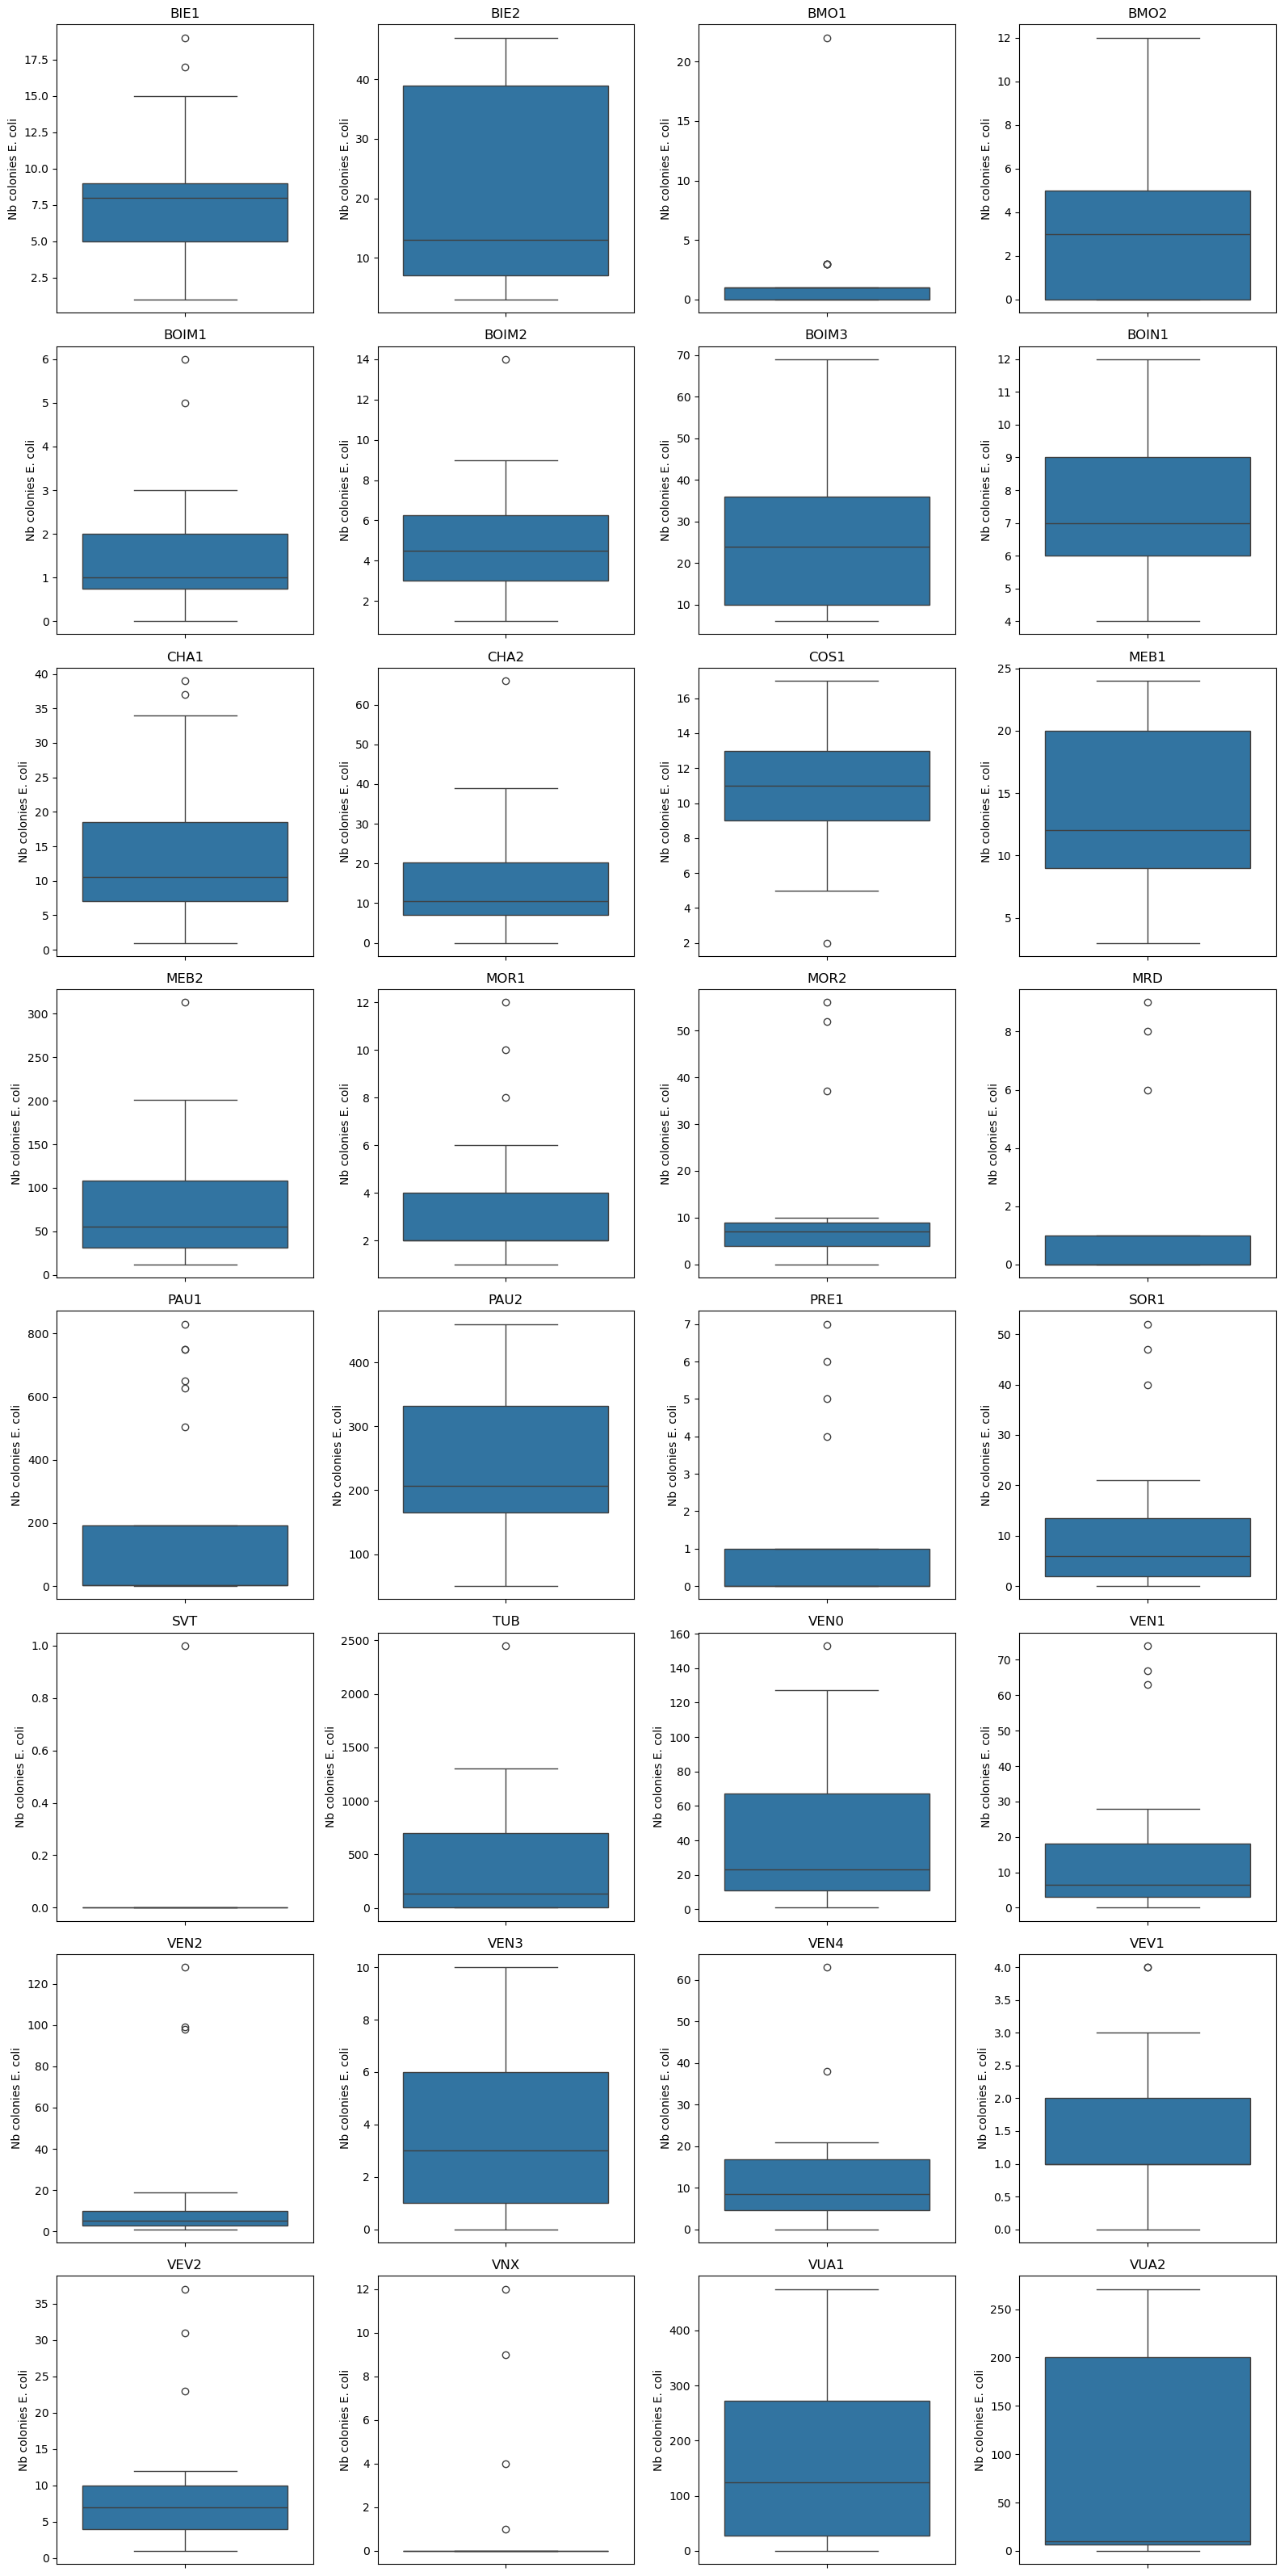

In [28]:
plotBySite(df, "Nb colonies E. coli", "boxplot")

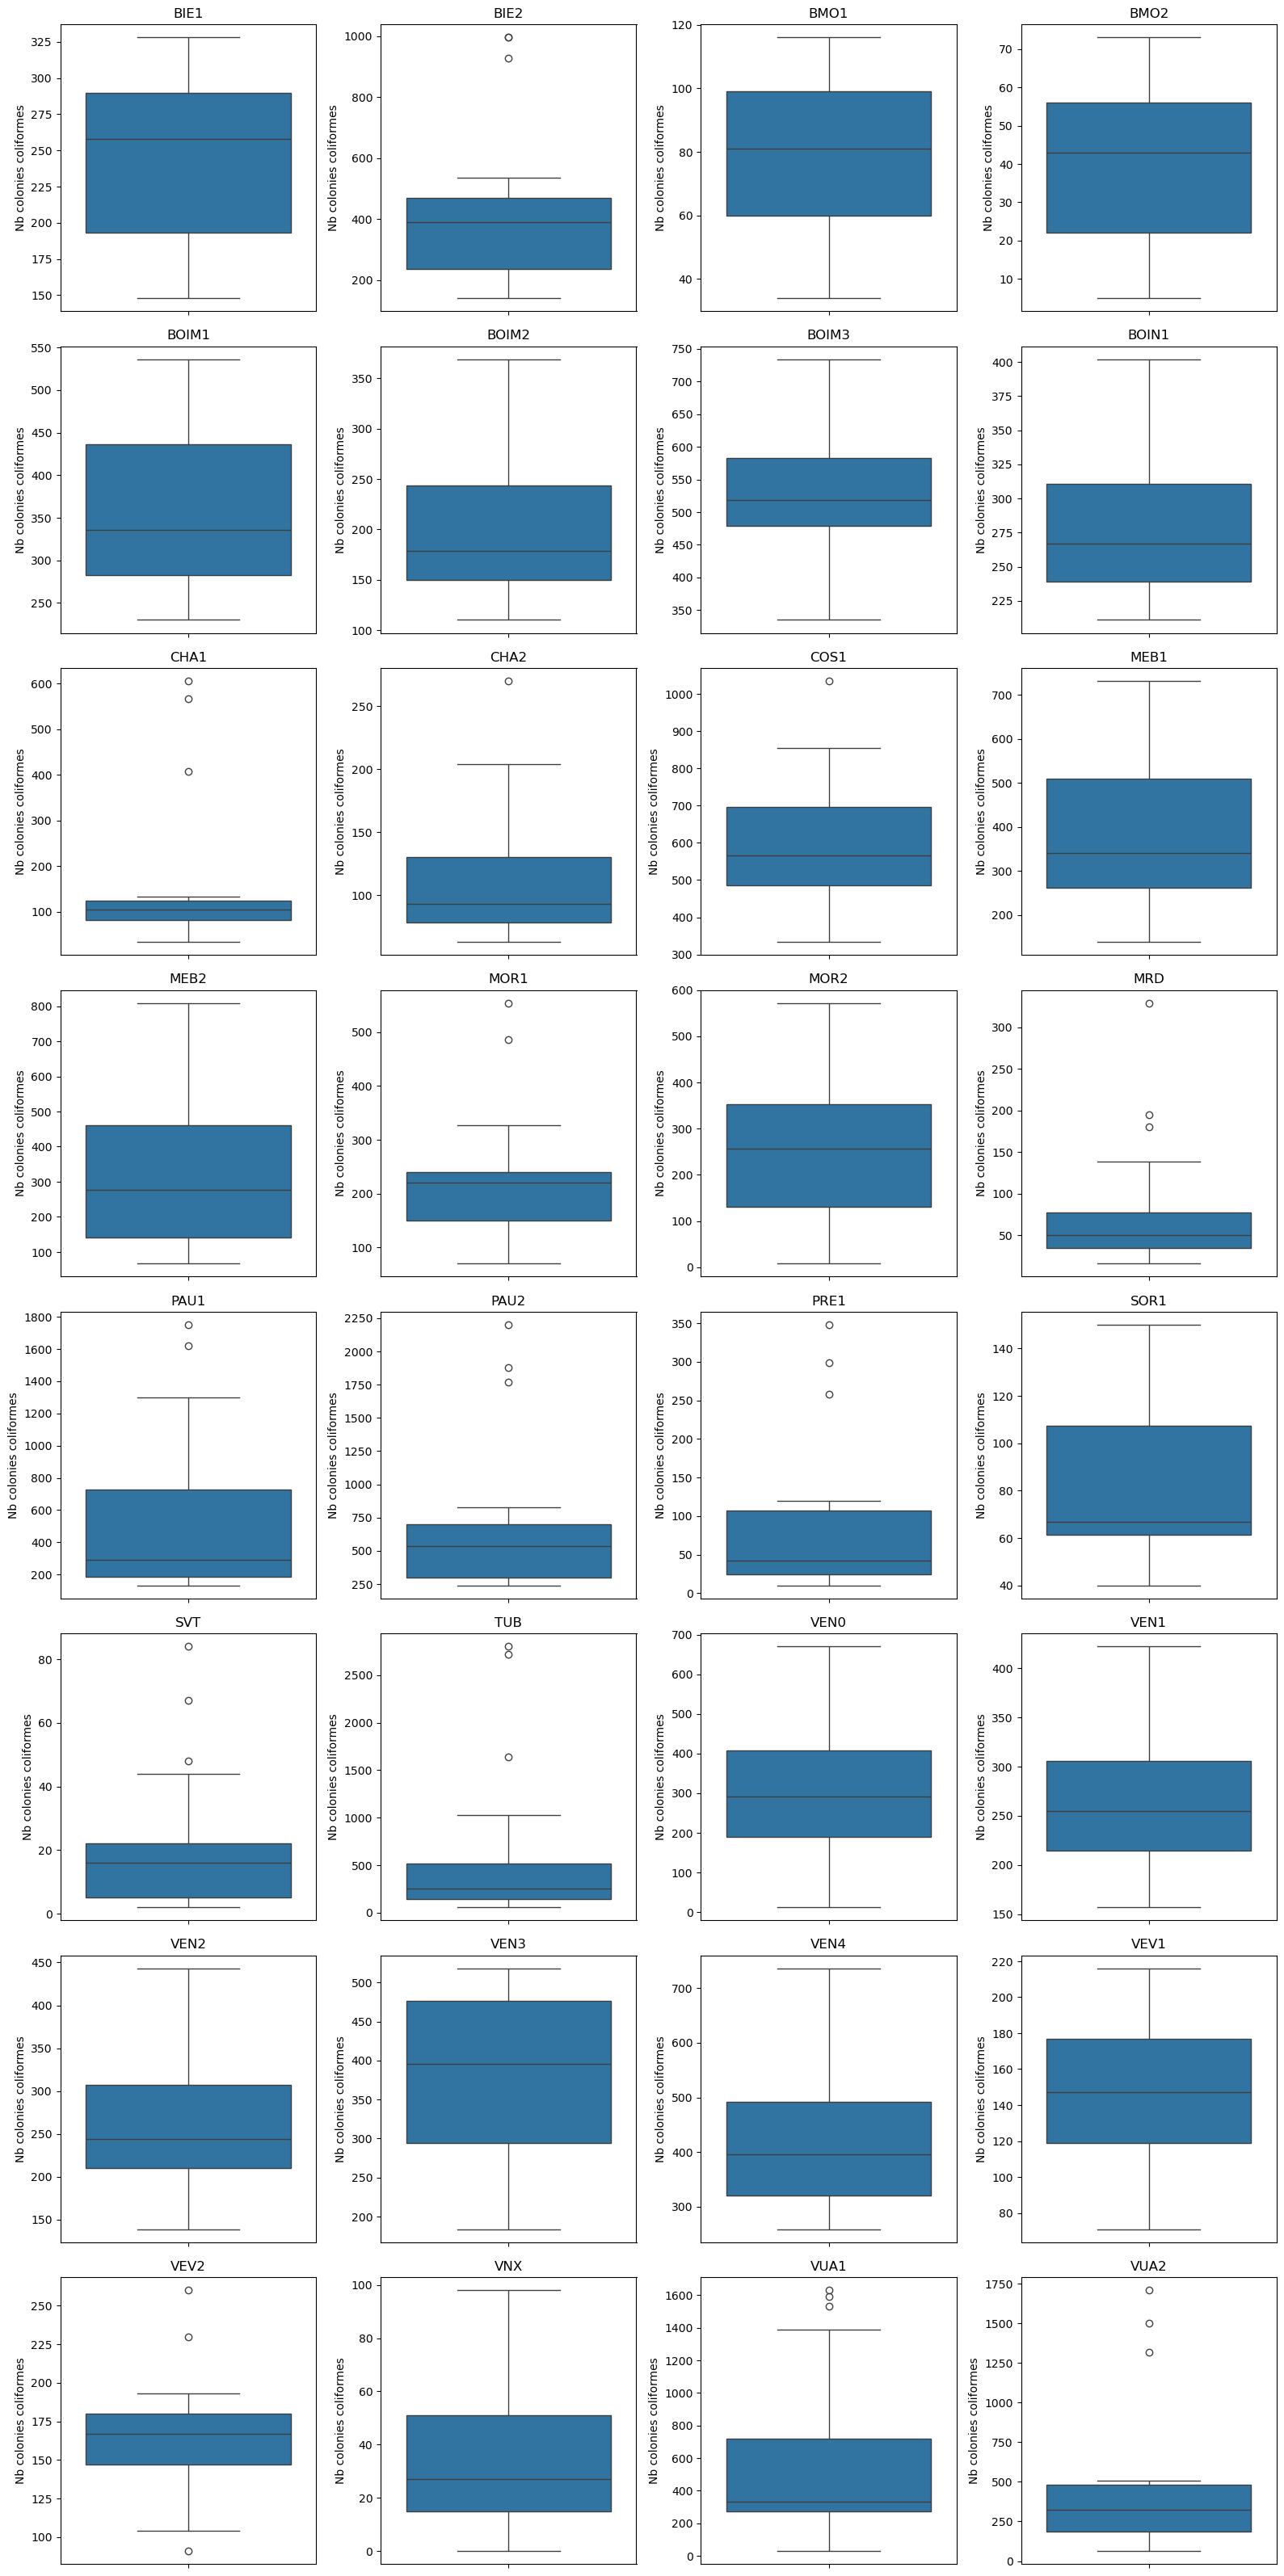

In [29]:
plotBySite(df, "Nb colonies coliformes", "boxplot")

In [30]:
sites = np.unique(df['ID site'])

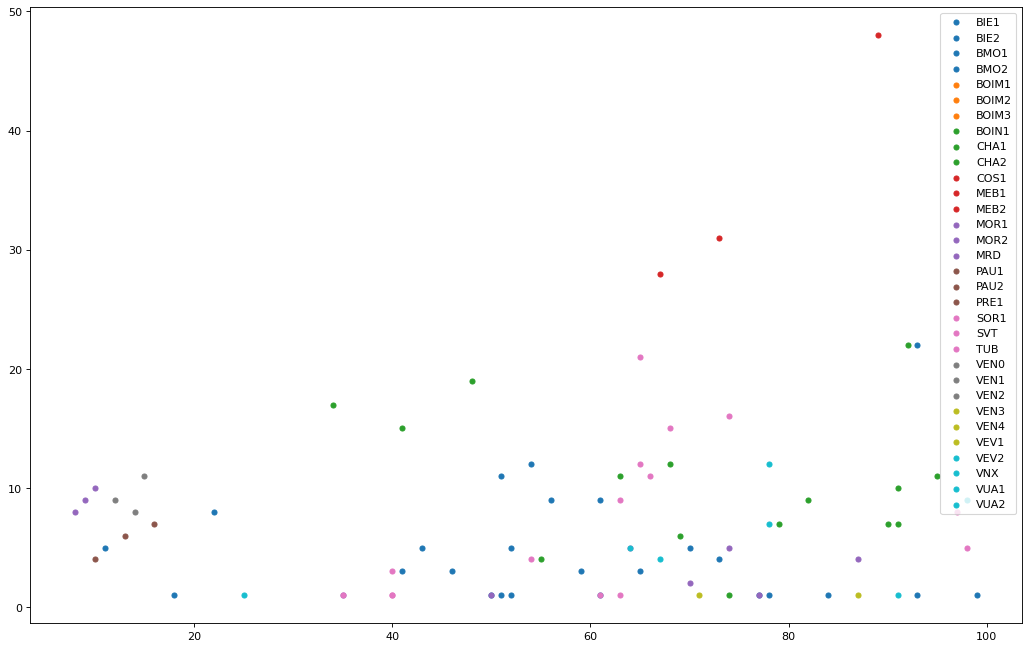

In [31]:
colors = [plt.cm.tab10(i/float(len(sites)-1)) for i in range(len(sites))]

df2 = df[(df['Nb colonies E. coli'] > 0) & (df['Nb colonies E. coli'] < 100) & (df['Nb colonies coliformes'] < 100) & (df['Nb colonies coliformes'] > 0)]

plt.figure(figsize=(16, 10), dpi= 80, facecolor='w', edgecolor='k')

for i, site in enumerate(sites):
    plt.scatter('Nb colonies coliformes', 'Nb colonies E. coli', 
                data=df2.loc[df2['ID site']==site, :], 
                s=20, color=colors[i], label=str(site))

plt.legend();

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_85274/1691755765.py:4: UserWarning: 
The palette list has fewer values (7) than needed (32) and will cycle, which may produce an uninterpretable plot.
  ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='ID site', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)


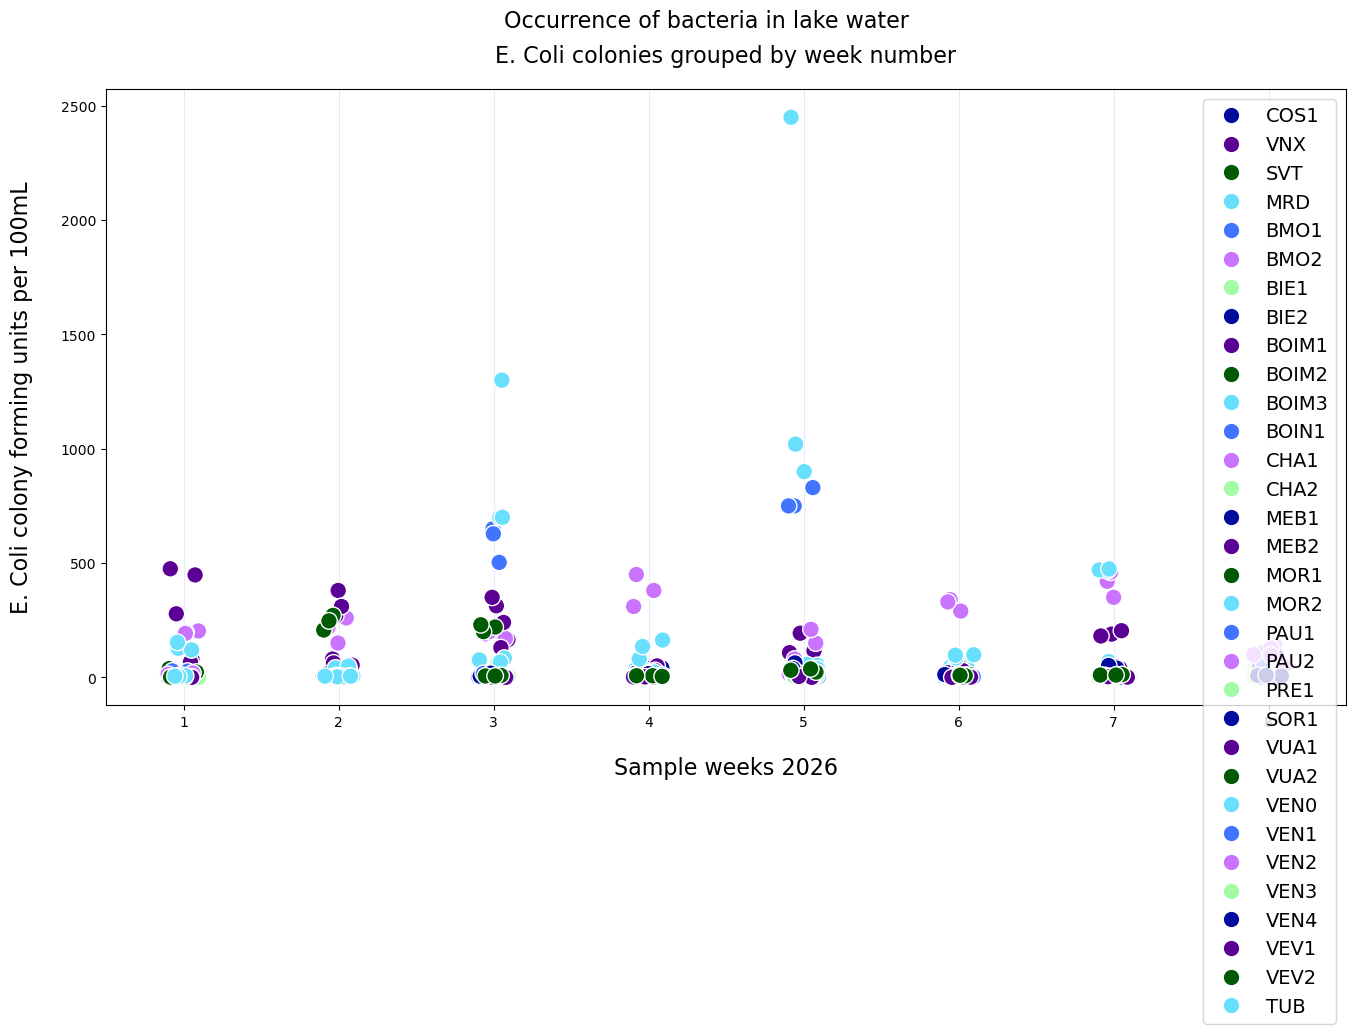

In [32]:
colors = ['#000A9C', '#5B0094', '#005903', '#68DFFC', '#4275FF', '#C973FF', '#A2FCA5']
fig, ax = plt.subplots(figsize=(16,8))

ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='ID site', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel("E. Coli colony forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in lake water" , fontsize=16, family='sans')
plt.title("E. Coli colonies grouped by week number", fontsize=16, family='sans', y=1.03)
ax.legend(loc='upper right', fontsize=14);